# E-commerce Analytics - Big Data Platform
## Analiza 4 modułów: Realtime, Funnel, Rekomendacje, Brand Performance

In [60]:
import happybase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja wykresów
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Połączenie z HBase
connection = happybase.Connection('localhost', port=9090)
print("Połączono z HBase")
print(f"Dostępne tabele: {connection.tables()}")
connection.close()

Połączono z HBase
Dostępne tabele: [b'brand_performance', b'funnel_analytics', b'personalized_recommendations', b'realtime_stats']


## 1. Analiza w czasie rzeczywistym (Realtime Analytics)
### Metryki z 5-minutowych okien czasowych

✓ Pobrano dane z 73 okien


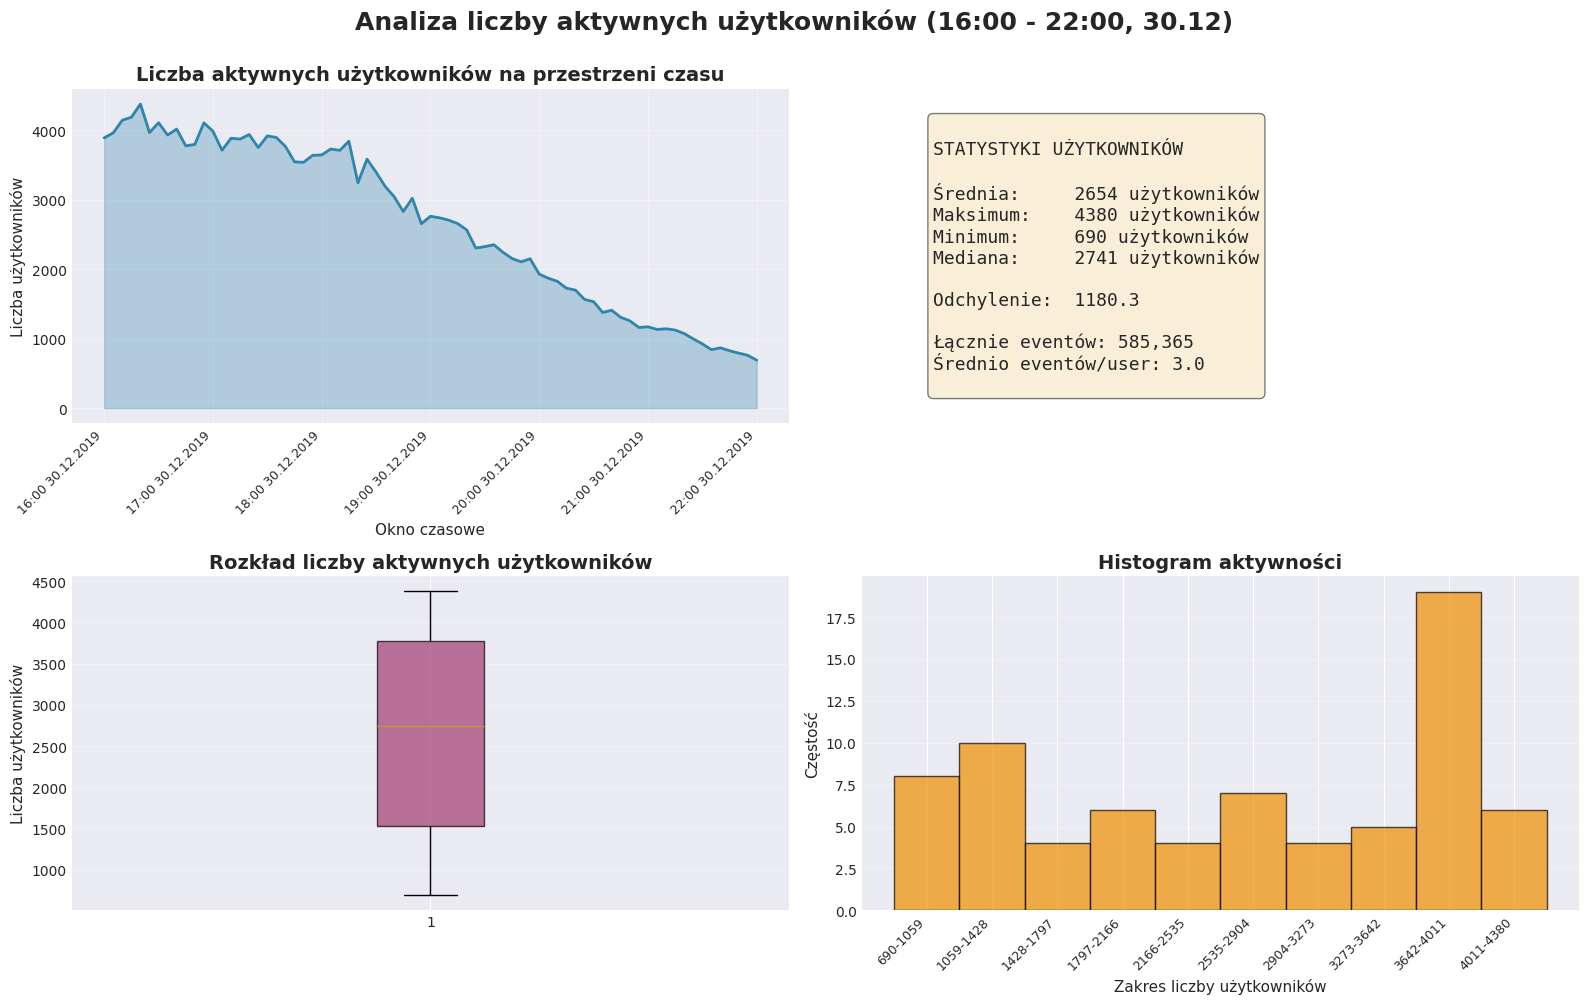

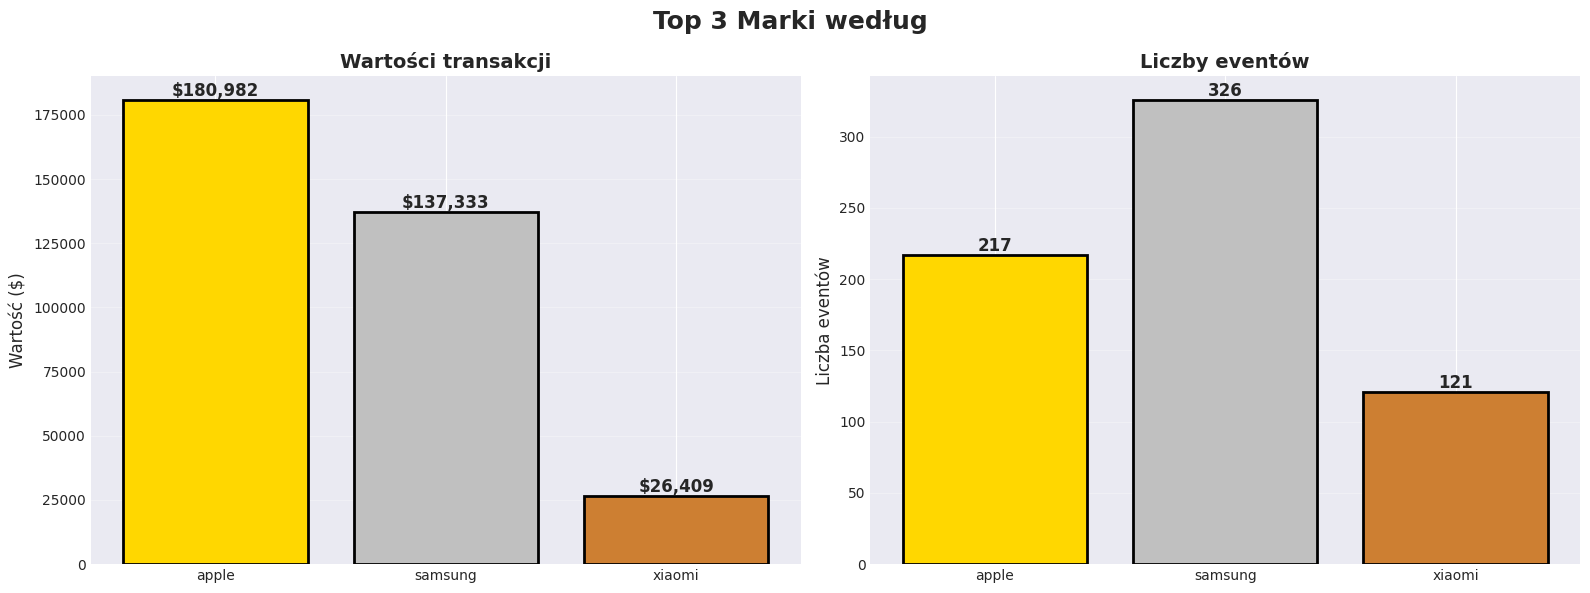

TOP 3 MARKI - SZCZEGÓŁY
1. apple
   Wartość:  $180,982.02
   Eventy:   217
   Średnia:  $834.02/event

2. samsung
   Wartość:  $137,332.64
   Eventy:   326
   Średnia:  $421.27/event

3. xiaomi
   Wartość:  $26,408.56
   Eventy:   121
   Średnia:  $218.25/event



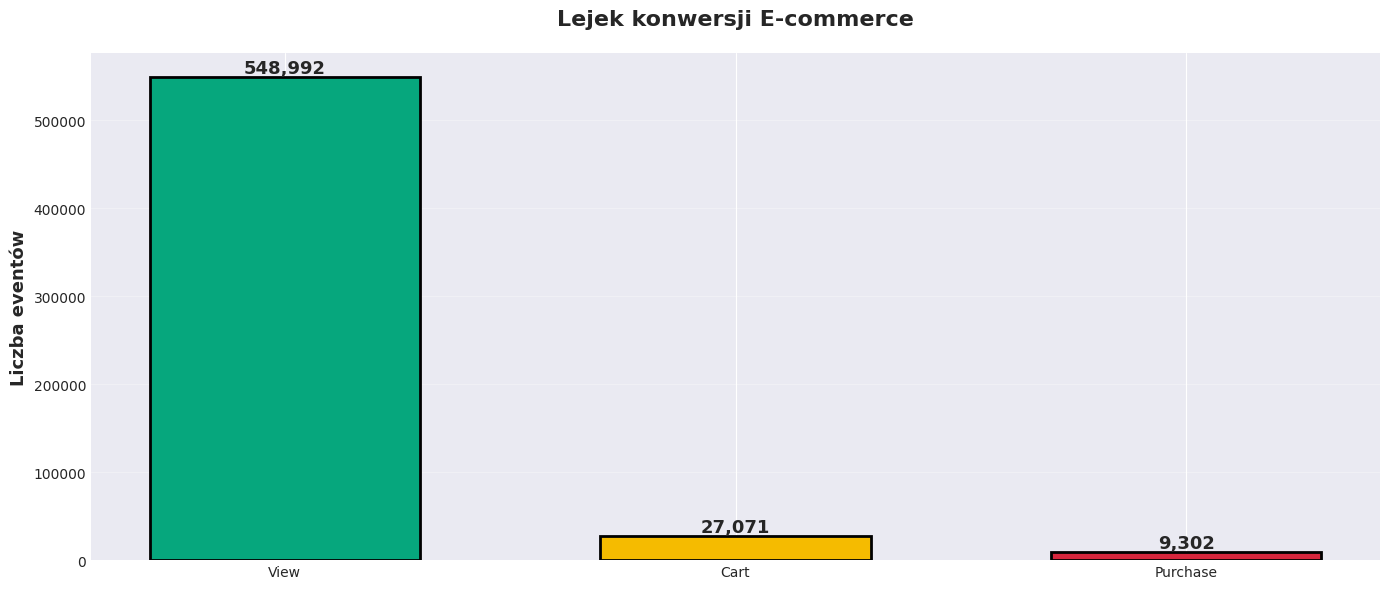


🎯 Konwersja View → Cart: 4.93%
🎯 Konwersja Cart → Purchase: 34.36%
🎯 Konwersja View → Purchase: 1.69%


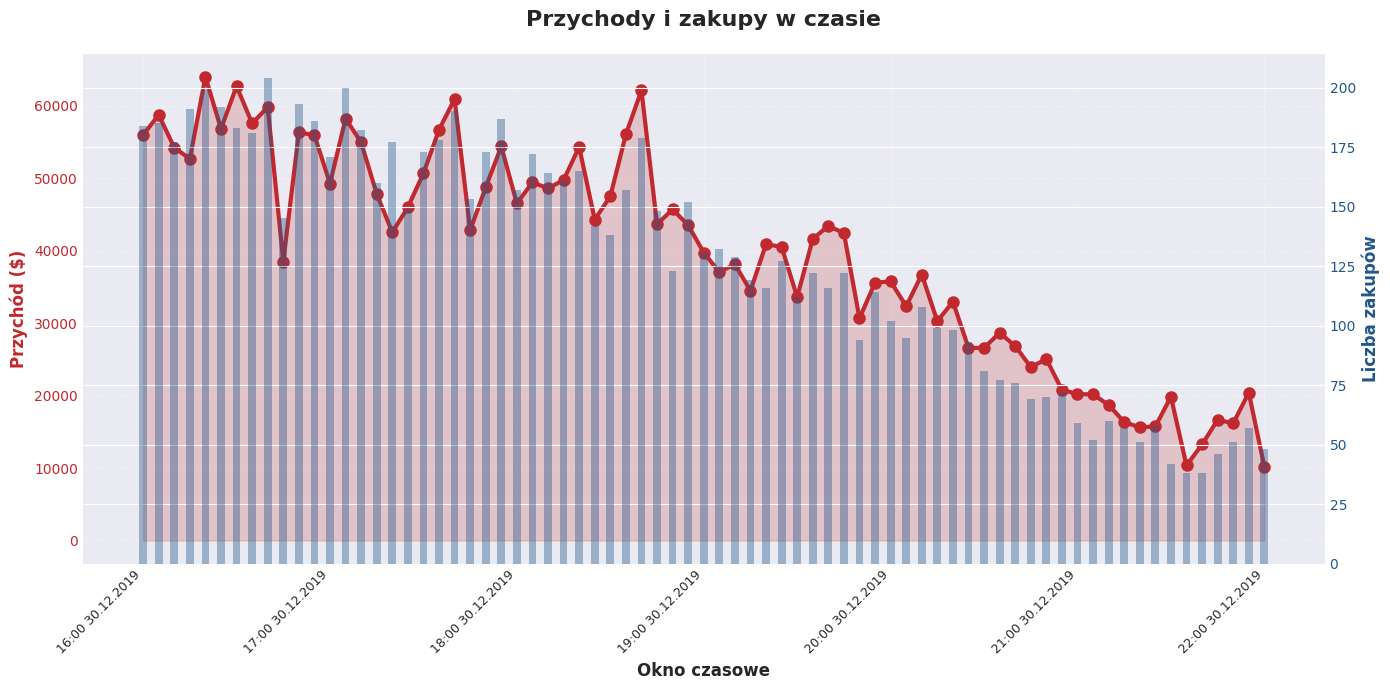

💰 Łączny przychód: $2,896,632.86
🛒 Łączne zakupy: 9302
📊 Średnia wartość koszyka: $316.16


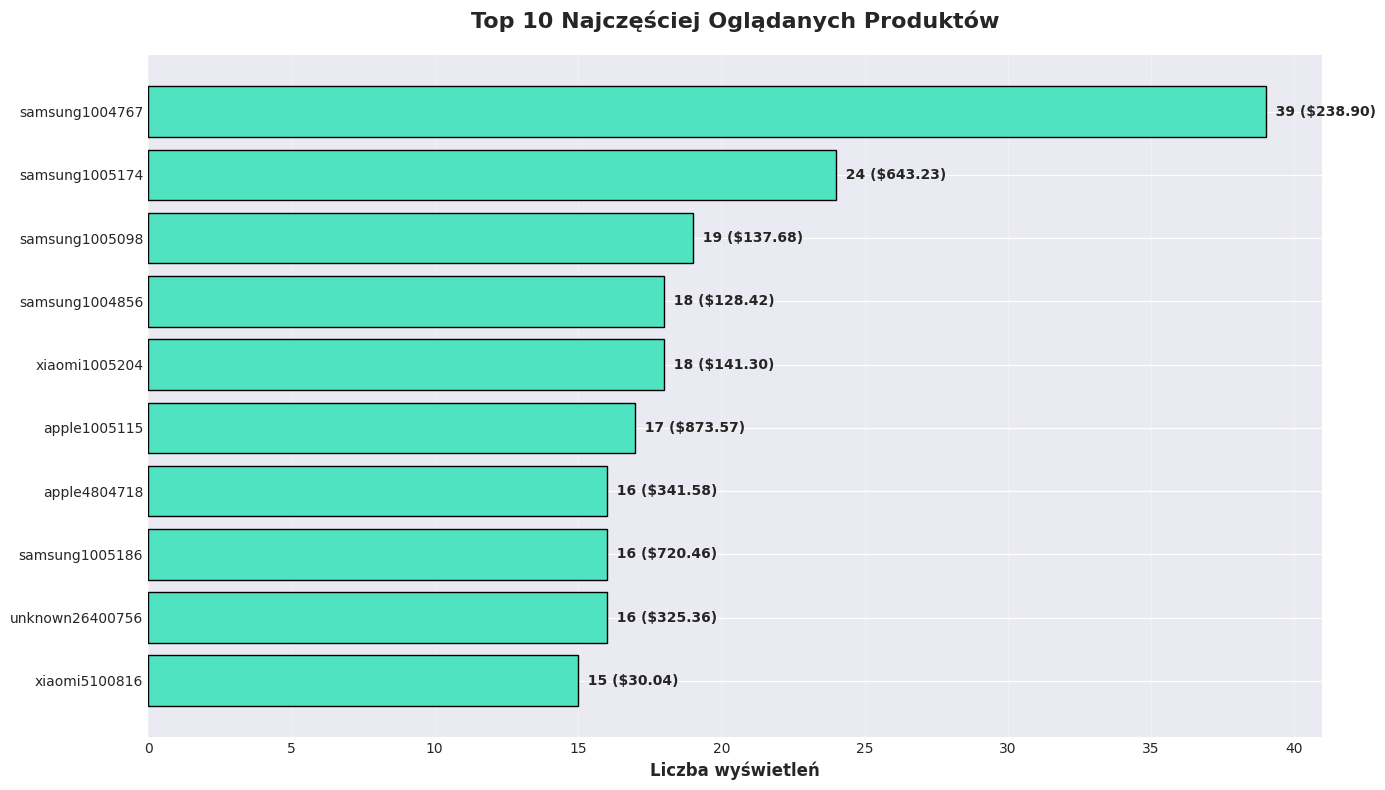

PODSUMOWANIE
📅 Analizowanych okien czasowych: 73
👥 Średnia liczba aktywnych użytkowników: 2654
📊 Łączna liczba eventów: 585,365
🏆 Najpopularniejsza marka: apple ($180,982.02)
🛍️ Najczęściej oglądany produkt: samsung
Połączenie z HBase zamknięte


In [18]:
# ============================================================================
# Big Data HBase
# ============================================================================

import happybase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Połączenie
connection = happybase.Connection('localhost', port=9090)
table = connection.table('realtime_stats')


def generate_window_keys(start_time, end_time, interval_minutes=5):
    """Generuje klucze okien czasowych w podanym przedziale"""
    keys = []
    current = datetime.strptime(start_time, '%Y%m%d_%H%M')
    end = datetime.strptime(end_time, '%Y%m%d_%H%M')
    
    while current <= end:
        keys.append(current.strftime('%Y%m%d_%H%M'))
        current += timedelta(minutes=interval_minutes)
    
    return keys

def window_to_datetime(window_key):
    """Konwertuje '20191230_1600' -> '16:00 30.12.2019'"""
    date_part = window_key.split('_')[0]  # '20191230'
    time_part = window_key.split('_')[1]  # '1600'
    
    year = date_part[:4]
    month = date_part[4:6]
    day = date_part[6:8]
    hour = time_part[:2]
    minute = time_part[2:]
    
    return f"{hour}:{minute} {day}.{month}.{year}"

# Przedział 16:00 - 22:00 (30 grudnia 2019)
window_keys = generate_window_keys('20191230_1600', '20191230_2200', interval_minutes=5)

# Struktury na dane
all_active_users = []
all_brands = {}
all_products = {}
all_events = []
all_purchases = []

# ============================================================================
# POBIERANIE DANYCH Z WIELU OKIEN
# ============================================================================
for window_key in window_keys:
    
    rows = list(table.scan(
        row_start=window_key.encode(),
        row_stop=f"{window_key}~".encode()
    ))
    
    for key, data in rows:
        key_str = key.decode()
        
        # ACTIVE USERS
        if 'active_users' in key_str:
            all_active_users.append({
                'window': window_key,
                'active_users': int(data.get(b'metrics:active_users', 0)),
                'total_events': int(data.get(b'metrics:total_events', 0)),
                'window_start': data.get(b'metrics:window_start', b'').decode()
            })
        
        # PURCHASES
        elif 'purchases' in key_str and 'event' not in key_str:
            all_purchases.append({
                'window': window_key,
                'purchase_count': int(data.get(b'metrics:purchase_count', 0)),
                'revenue': float(data.get(b'metrics:total_revenue', b'0')),
                'avg_basket': float(data.get(b'metrics:avg_basket_value', b'0')),
                'buyers': int(data.get(b'metrics:purchasing_users', 0))
            })
        
        # EVENTS
        elif 'event_view' in key_str:
            all_events.append({
                'window': window_key,
                'type': 'view',
                'count': int(data.get(b'metrics:event_count', 0))
            })
        elif 'event_cart' in key_str:
            all_events.append({
                'window': window_key,
                'type': 'cart',
                'count': int(data.get(b'metrics:event_count', 0))
            })
        elif 'event_purchase' in key_str:
            all_events.append({
                'window': window_key,
                'type': 'purchase',
                'count': int(data.get(b'metrics:event_count', 0))
            })
        
        # BRANDS (z deduplikacją)
        elif 'brand_' in key_str:
            brand = data.get(b'metrics:brand', b'').decode()
            event_type = data.get(b'metrics:event_type', b'').decode()
            created_at = data.get(b'metadata:created_at', b'').decode()
            unique_key = f"{brand}_{event_type}"
            
            if unique_key not in all_brands or created_at > all_brands[unique_key]['created_at']:
                all_brands[unique_key] = {
                    'brand': brand,
                    'event_type': event_type,
                    'event_count': int(data.get(b'metrics:event_count', 0)),
                    'total_value': float(data.get(b'metrics:total_value', b'0')),
                    'created_at': created_at
                }
        
        # PRODUCTS
        elif 'top_view' in key_str:
            product_id = data.get(b'metrics:product_id', b'').decode()
            created_at = data.get(b'metadata:created_at', b'').decode()
            
            if product_id not in all_products or created_at > all_products[product_id]['created_at']:
                all_products[product_id] = {
                    'product_id': product_id,
                    'brand': data.get(b'metrics:brand', b'').decode(),
                    'view_count': int(data.get(b'metrics:view_count', 0)),
                    'price': float(data.get(b'metrics:avg_price', b'0')),
                    'category': data.get(b'metrics:category', b'').decode(),
                    'created_at': created_at
                }

print(f"✓ Pobrano dane z {len(window_keys)} okien")

# Konwersja do DataFrames
df_active = pd.DataFrame(all_active_users)
df_brands = pd.DataFrame(list(all_brands.values()))
df_products = pd.DataFrame(list(all_products.values()))
df_events = pd.DataFrame(all_events)
df_purchases = pd.DataFrame(all_purchases)

# ============================================================================
# WYKRES 1: AKTYWNI UŻYTKOWNICY W CZASIE + STATYSTYKI
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analiza liczby aktywnych użytkowników (16:00 - 22:00, 30.12)', 
             fontsize=18, fontweight='bold', y=1.00)

# Wykres liniowy
ax1 = axes[0, 0]
ax1.plot(range(len(df_active)), df_active['active_users'], 
         linewidth=2, color='#2E86AB')
ax1.fill_between(range(len(df_active)), df_active['active_users'], alpha=0.3, color='#2E86AB')
ax1.set_title('Liczba aktywnych użytkowników na przestrzeni czasu', fontsize=14, fontweight='bold')
ax1.set_xlabel('Okno czasowe', fontsize=11)
ax1.set_ylabel('Liczba użytkowników', fontsize=11)
hour_indices = [i for i, w in enumerate(df_active['window']) if w.endswith('00')]
hour_labels = [window_to_datetime(df_active['window'].iloc[i]) for i in hour_indices]
ax1.set_xticks(hour_indices)
ax1.set_xticklabels(hour_labels, rotation=45, ha='right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Statystyki w formie tekstu
ax2 = axes[0, 1]
ax2.axis('off')
stats_text = f"""
STATYSTYKI UŻYTKOWNIKÓW

Średnia:     {df_active['active_users'].mean():.0f} użytkowników
Maksimum:    {df_active['active_users'].max():.0f} użytkowników
Minimum:     {df_active['active_users'].min():.0f} użytkowników
Mediana:     {df_active['active_users'].median():.0f} użytkowników

Odchylenie:  {df_active['active_users'].std():.1f}

Łącznie eventów: {df_active['total_events'].sum():,}
Średnio eventów/user: {df_active['total_events'].sum() / df_active['active_users'].sum():.1f}
"""
ax2.text(0.1, 0.5, stats_text, fontsize=13, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot
ax3 = axes[1, 0]
ax3.boxplot(df_active['active_users'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#A23B72', alpha=0.7))
ax3.set_title('Rozkład liczby aktywnych użytkowników', fontsize=14, fontweight='bold')
ax3.set_ylabel('Liczba użytkowników', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# Histogram
ax4 = axes[1, 1]
n, bins, patches = ax4.hist(df_active['active_users'], bins=10, 
                             color='#F18F01', alpha=0.7, edgecolor='black')

ax4.set_title('Histogram aktywności', fontsize=14, fontweight='bold')
ax4.set_xlabel('Zakres liczby użytkowników', fontsize=11)
ax4.set_ylabel('Częstość', fontsize=11)

# Oblicz środki bins dla pozycji etykiet
bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

# Stwórz etykiety z zakresami
bin_labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]

ax4.set_xticks(bin_centers)
ax4.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.subplots_adjust(hspace=0.3)  # Zwiększ odstęp pionowy (domyślnie ~0.2)
plt.tight_layout()
plt.show()


# ============================================================================
# WYKRES 2: TOP 3 MARKI WEDŁUG WARTOŚCI TRANSAKCJI
# ============================================================================
# Agreguj marki i posortuj
brand_aggregated = df_brands.groupby('brand').agg({
    'event_count': 'sum',
    'total_value': 'sum'
}).sort_values('total_value', ascending=False)

top3_brands = brand_aggregated.head(3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 3 Marki według ', fontsize=18, fontweight='bold')

# Wykres słupkowy wartości
colors = ['#FFD700', '#C0C0C0', '#CD7F32']  # Złoto, srebro, brąz
bars1 = ax1.bar(top3_brands.index, top3_brands['total_value'], color=colors, edgecolor='black', linewidth=2)
ax1.set_title('Wartości transakcji', fontsize=14, fontweight='bold')
ax1.set_ylabel('Wartość ($)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# Dodaj wartości na słupkach
for i, (idx, val) in enumerate(top3_brands['total_value'].items()):
    ax1.text(i, val, f'${val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Wykres liczby eventów
bars2 = ax2.bar(top3_brands.index, top3_brands['event_count'], color=colors, edgecolor='black', linewidth=2)
ax2.set_title('Liczby eventów', fontsize=14, fontweight='bold')
ax2.set_ylabel('Liczba eventów', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Dodaj wartości na słupkach
for i, (idx, val) in enumerate(top3_brands['event_count'].items()):
    ax2.text(i, val, f'{int(val):,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.subplots_adjust(hspace=0.3)  # Zwiększ odstęp pionowy (domyślnie ~0.2)
plt.tight_layout()
plt.show()

# Wyświetl szczegóły
print("="*60)
print("TOP 3 MARKI - SZCZEGÓŁY")
print("="*60)
for i, (brand, row) in enumerate(top3_brands.iterrows(), 1):
    print(f"{i}. {brand}")
    print(f"   Wartość:  ${row['total_value']:,.2f}")
    print(f"   Eventy:   {int(row['event_count']):,}")
    print(f"   Średnia:  ${row['total_value']/row['event_count']:.2f}/event")
    print()

# ============================================================================
# WYKRES 3: LEJEK KONWERSJI
# ============================================================================
# Przygotuj dane eventów
event_pivot = df_events.groupby('type')['count'].sum()

fig, ax = plt.subplots(figsize=(14, 6))

stages = ['View', 'Cart', 'Purchase']
values = [
    event_pivot.get('view', 0),
    event_pivot.get('cart', 0),
    event_pivot.get('purchase', 0)
]
colors = ['#06A77D', '#F5BB00', '#D7263D']

bars = ax.bar(stages, values, color=colors, edgecolor='black', linewidth=2, width=0.6)

# Wartości na słupkach
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{int(val):,}', 
           ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Liczba eventów', fontsize=13, fontweight='bold')
ax.set_title('Lejek konwersji E-commerce', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statystyki
print(f"\n🎯 Konwersja View → Cart: {(values[1]/values[0]*100):.2f}%")
print(f"🎯 Konwersja Cart → Purchase: {(values[2]/values[1]*100):.2f}%")
print(f"🎯 Konwersja View → Purchase: {(values[2]/values[0]*100):.2f}%")



# ============================================================================
# WYKRES 5: PURCHASES I REVENUE W CZASIE
# ============================================================================
if len(df_purchases) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    color1 = '#C1292E'
    ax1.set_xlabel('Okno czasowe', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Przychód ($)', fontsize=12, fontweight='bold', color=color1)
    line1 = ax1.plot(range(len(df_purchases)), df_purchases['revenue'], 
             color=color1, marker='o', linewidth=3, markersize=8, label='Przychód')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.fill_between(range(len(df_purchases)), df_purchases['revenue'], alpha=0.2, color=color1)
    
    ax2 = ax1.twinx()
    color2 = '#235789'
    ax2.set_ylabel('Liczba zakupów', fontsize=12, fontweight='bold', color=color2)
    bars = ax2.bar(range(len(df_purchases)), df_purchases['purchase_count'], 
            color=color2, alpha=0.4, width=0.5, label='Zakupy')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    hour_indices = [i for i, w in enumerate(df_purchases['window']) if w.endswith('00')]
    hour_labels = [window_to_datetime(df_purchases['window'].iloc[i]) for i in hour_indices]
    
    ax1.set_xticks(hour_indices)
    ax1.set_xticklabels(hour_labels, rotation=45, ha='right', fontsize=9)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    plt.title('Przychody i zakupy w czasie', fontsize=16, fontweight='bold', pad=20)
    fig.tight_layout()
    plt.show()
    
    print(f"💰 Łączny przychód: ${df_purchases['revenue'].sum():,.2f}")
    print(f"🛒 Łączne zakupy: {df_purchases['purchase_count'].sum():.0f}")
    print(f"📊 Średnia wartość koszyka: ${df_purchases['avg_basket'].mean():.2f}")

# ============================================================================
# WYKRES 6: TOP 10 PRODUKTÓW
# ============================================================================
top10_products = df_products.nlargest(10, 'view_count')

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(range(len(top10_products)), top10_products['view_count'], color='#50E3C2', edgecolor='black')
ax.set_yticks(range(len(top10_products)))
ax.set_yticklabels([(f"{row['brand'][:20]}" + f"{row['product_id'][:20]}") for _, row in top10_products.iterrows()])
ax.set_xlabel('Liczba wyświetleń', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Najczęściej Oglądanych Produktów', fontsize=16, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Dodaj wartości i ceny
for i, (_, row) in enumerate(top10_products.iterrows()):
    ax.text(row['view_count'], i, f"  {int(row['view_count']):,} (${row['price']:.2f})", 
           va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# PODSUMOWANIE
# ============================================================================
print( "="*80)
print("PODSUMOWANIE")
print("="*80)
print(f"📅 Analizowanych okien czasowych: {len(window_keys)}")
print(f"👥 Średnia liczba aktywnych użytkowników: {df_active['active_users'].mean():.0f}")
print(f"📊 Łączna liczba eventów: {df_active['total_events'].sum():,}")
print(f"🏆 Najpopularniejsza marka: {brand_aggregated.index[0]} (${brand_aggregated.iloc[0]['total_value']:,.2f})")
print(f"🛍️ Najczęściej oglądany produkt: {top10_products.iloc[0]['brand']}")
print("="*80)

connection.close()
print("Połączenie z HBase zamknięte")


## 2. Analiza lejka zakupowego (Funnel Analytics)
### View → Add to Cart → Purchase

✓ Pobrano 13258 rekordów z funnel_analytics


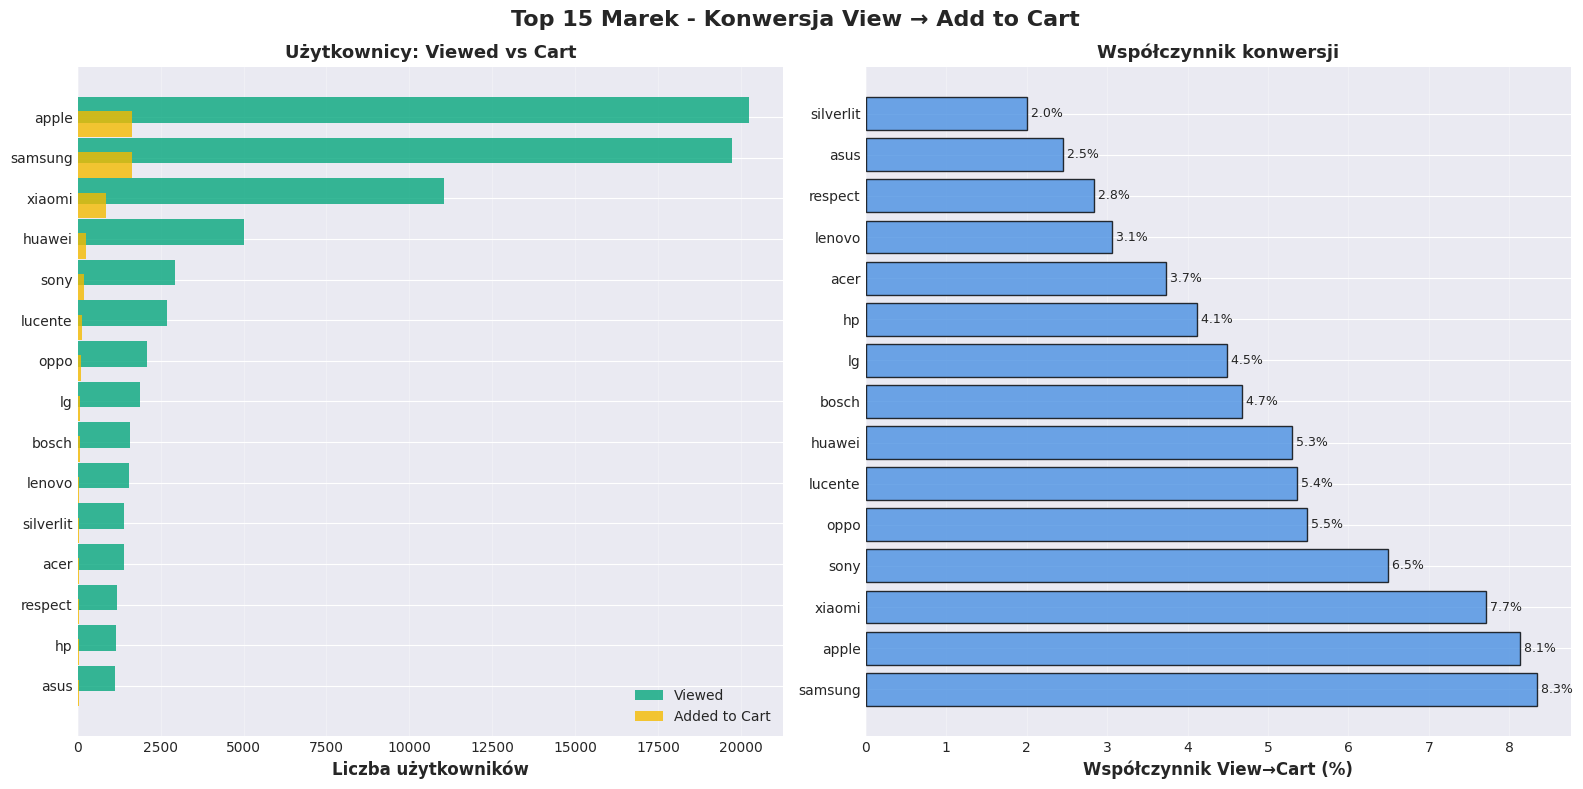

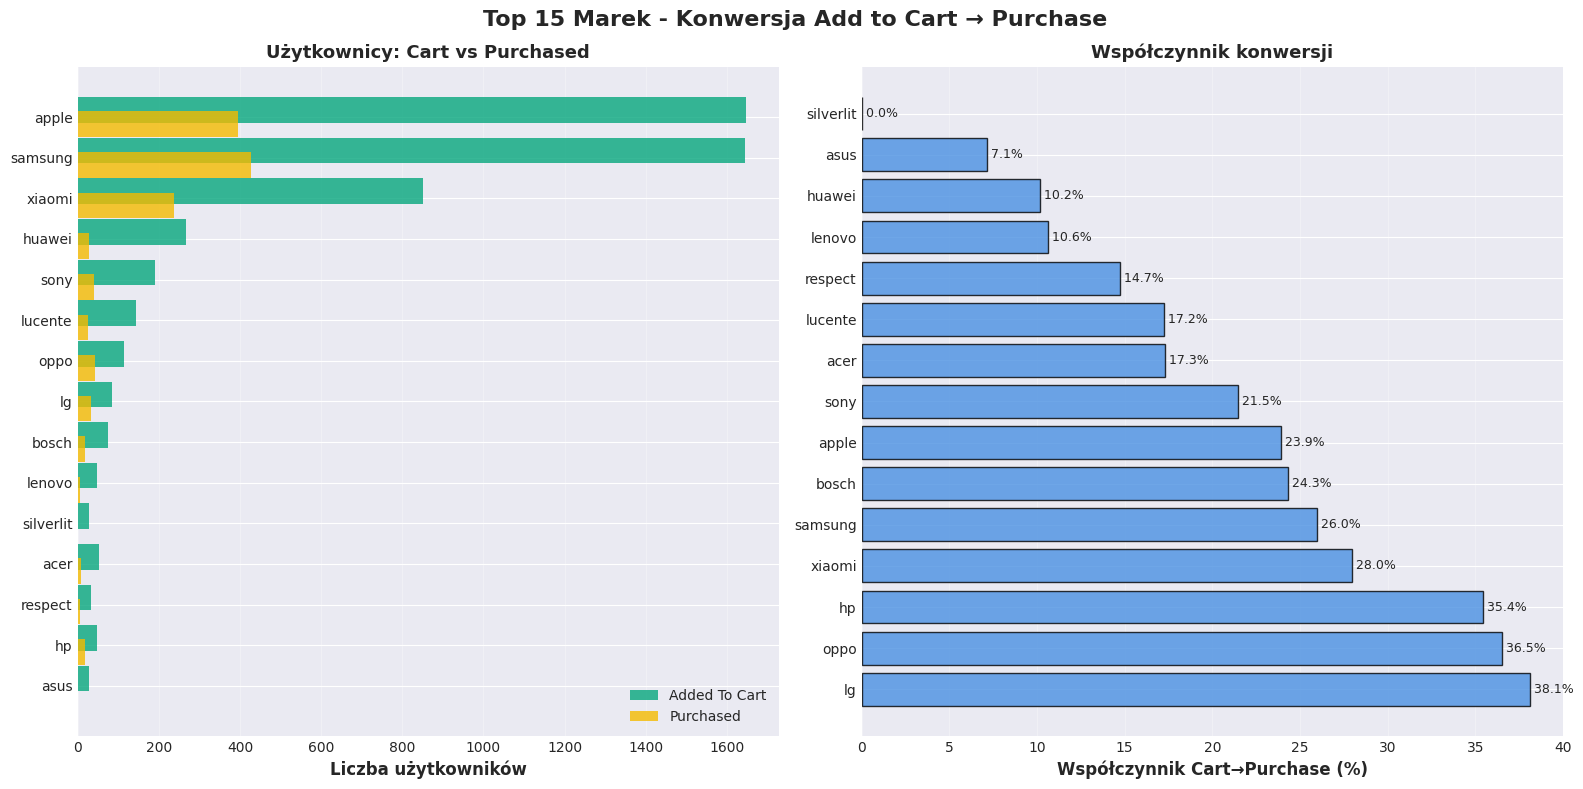

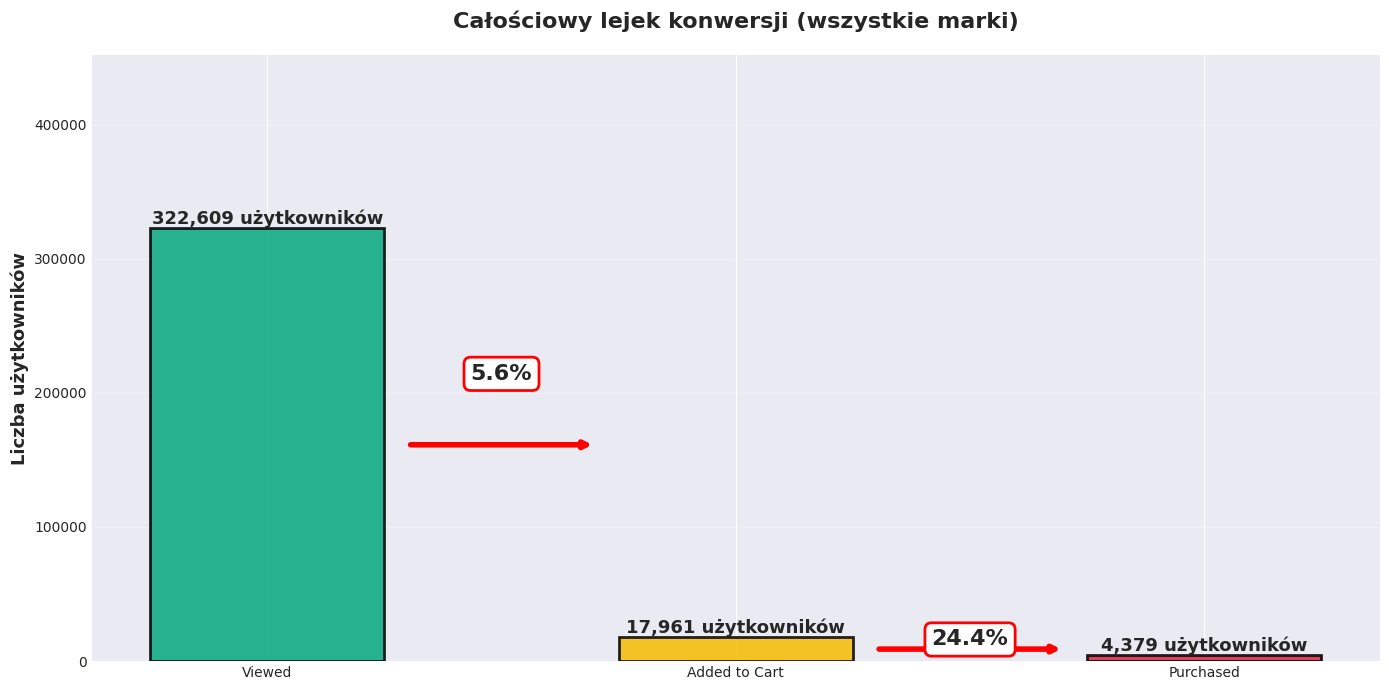

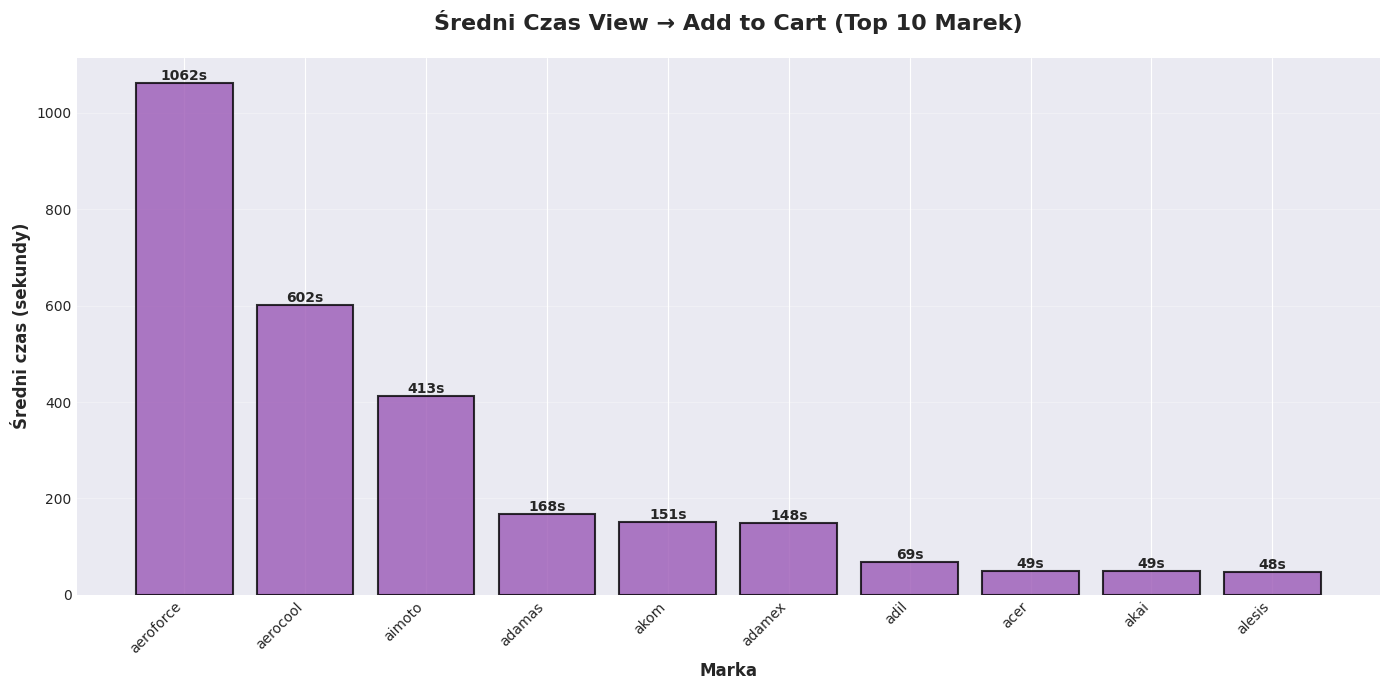

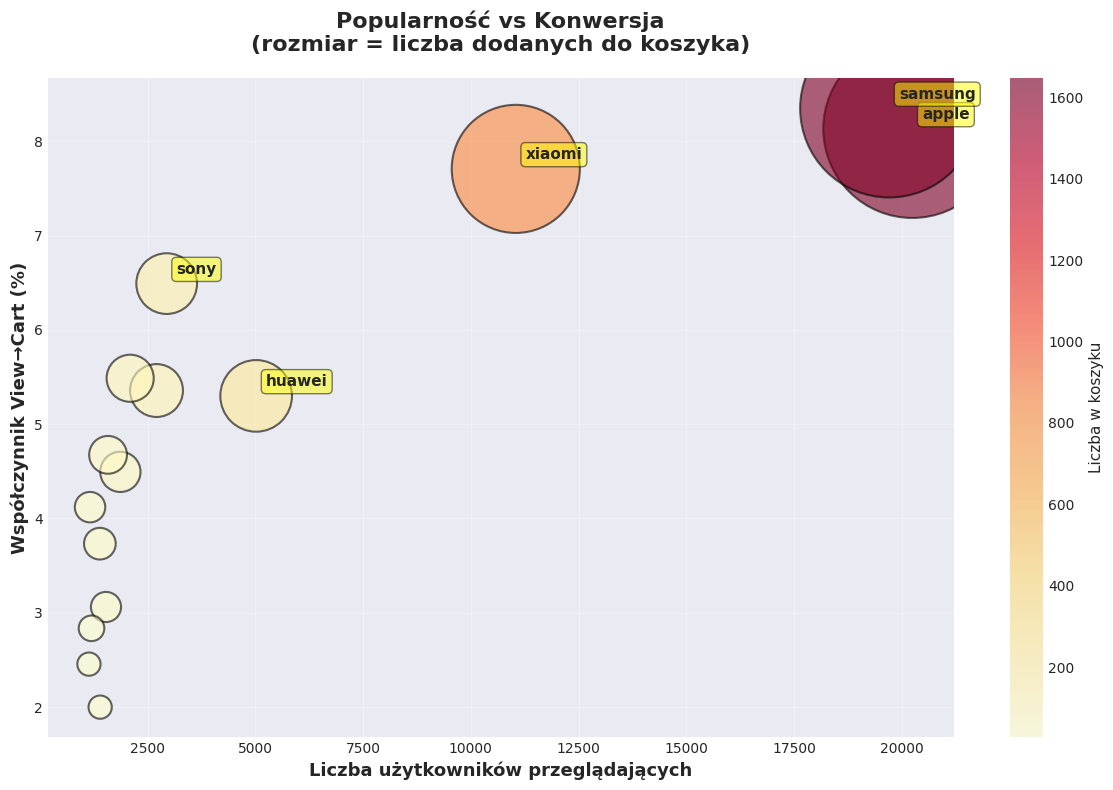

STATYSTYKI View → Add to Cart
📊 Całościowe liczby:
   • Viewed: 322,609 użytkowników
   • Added to Cart: 17,961 użytkowników
   • Konwersja: 5.57%
🏆 Top 5 marek według liczby viewed:
   1. apple: 20,245 viewed → 1646 cart (8.13%)
   2. samsung: 19,707 viewed → 1645 cart (8.35%)
   3. xiaomi: 11,043 viewed → 851 cart (7.71%)
   4. huawei: 5,019 viewed → 266 cart (5.30%)
   5. sony: 2,943 viewed → 191 cart (6.49%)
⚡ Top 5 marek według współczynnika konwersji (min. 20 viewed):
   1. samsung: 8.35% (19707 viewed)
   2. apple: 8.13% (20245 viewed)
   3. xiaomi: 7.71% (11043 viewed)
   4. sony: 6.49% (2943 viewed)
   5. oppo: 5.49% (2096 viewed)
📈 Statystyki współczynnika View→Cart:
   • Średnia: 4.95%
   • Mediana: 4.67%
   • Najwyższy: 8.35%
   • Najniższy: 2.00%
✓ Połączenie zamknięte


In [20]:
# ============================================================================
# FUNNEL ANALYTICS
# ============================================================================

import happybase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

connection = happybase.Connection('localhost', port=9090)
table = connection.table('funnel_analytics')

# Pobierz dane 
data = []
for key, values in table.scan():
    row = {'row_key': key.decode()}
    for col, val in values.items():
        col_name = col.decode().split(':')[1]
        row[col_name] = val.decode()
    data.append(row)

df_funnel = pd.DataFrame(data)
print(f"✓ Pobrano {len(df_funnel)} rekordów z funnel_analytics")

# KONWERSJA NA LICZBY 
numeric_cols = ['users_viewed', 'users_added_to_cart', 'users_purchased',
                'view_to_cart_rate', 'cart_to_purchase_rate', 'view_to_purchase_rate',
                'avg_view_to_cart_seconds', 'avg_cart_to_purchase_seconds']

for col in numeric_cols:
    if col in df_funnel.columns:
        df_funnel[col] = pd.to_numeric(df_funnel[col], errors='coerce')

df_funnel = df_funnel[(df_funnel['users_viewed'] > 0) | 
                      (df_funnel['users_added_to_cart'] > 0) | 
                      (df_funnel['users_purchased'] > 0)]

# ============================================================================
# WYKRES 1: TOP 15 MAREK - View → Cart
# ============================================================================
brand_funnel = df_funnel[df_funnel['type'] == 'brand'].groupby('name').agg({
    'users_viewed': 'sum',
    'users_added_to_cart': 'sum',
    'users_purchased': 'sum'
}).sort_values('users_viewed', ascending=False).head(15)

brand_funnel['v2c_rate'] = (brand_funnel['users_added_to_cart'] / brand_funnel['users_viewed'] * 100)
brand_funnel['c2p_rate'] = (brand_funnel['users_purchased'] / brand_funnel['users_added_to_cart'] * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Top 15 Marek - Konwersja View → Add to Cart', fontsize=16, fontweight='bold')

# LEWY WYKRES - posortowane według viewed
x = np.arange(len(brand_funnel))
width = 0.35

ax1.barh(x - width/2, brand_funnel['users_viewed'], width*1.8, 
        label='Viewed', color='#06A77D', alpha=0.8)
ax1.barh(x + width/2, brand_funnel['users_added_to_cart'], width*1.8,
        label='Added to Cart', color='#F5BB00', alpha=0.8)

ax1.set_yticks(x)
ax1.set_yticklabels(brand_funnel.index, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Liczba użytkowników', fontsize=12, fontweight='bold')
ax1.set_title('Użytkownicy: Viewed vs Cart', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# PRAWY WYKRES - posortowane według współczynnika konwersji
brand_funnel_sorted = brand_funnel.sort_values('v2c_rate', ascending=True)  # ascending=True bo invert_yaxis()
x2 = np.arange(len(brand_funnel_sorted))

bars = ax2.barh(x2, brand_funnel_sorted['v2c_rate'], color='#4A90E2', alpha=0.8, edgecolor='black')
ax2.set_yticks(x2)
ax2.set_yticklabels(brand_funnel_sorted.index, fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Współczynnik View→Cart (%)', fontsize=12, fontweight='bold')
ax2.set_title('Współczynnik konwersji', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Dodaj wartości
for i, (idx, val) in enumerate(brand_funnel_sorted['v2c_rate'].items()):
    ax2.text(val, i, f' {val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Top 15 Marek - Konwersja Add to Cart → Purchase', fontsize=16, fontweight='bold')

# LEWY WYKRES 
x = np.arange(len(brand_funnel))
width = 0.35

ax1.barh(x - width/2, brand_funnel['users_added_to_cart'], width*1.8, 
        label='Added To Cart', color='#06A77D', alpha=0.8)
ax1.barh(x + width/2, brand_funnel['users_purchased'], width*1.8,
        label='Purchased', color='#F5BB00', alpha=0.8)

ax1.set_yticks(x)
ax1.set_yticklabels(brand_funnel.index, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Liczba użytkowników', fontsize=12, fontweight='bold')
ax1.set_title('Użytkownicy: Cart vs Purchased', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# PRAWY WYKRES 
brand_funnel_sorted = brand_funnel.sort_values('c2p_rate', ascending=True)  # ascending=True bo invert_yaxis()
x2 = np.arange(len(brand_funnel_sorted))

bars = ax2.barh(x2, brand_funnel_sorted['c2p_rate'], color='#4A90E2', alpha=0.8, edgecolor='black')
ax2.set_yticks(x2)
ax2.set_yticklabels(brand_funnel_sorted.index, fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Współczynnik Cart→Purchase (%)', fontsize=12, fontweight='bold')
ax2.set_title('Współczynnik konwersji', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Dodaj wartości
for i, (idx, val) in enumerate(brand_funnel_sorted['c2p_rate'].items()):
    ax2.text(val, i, f' {val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# WYKRES 2: CAŁOŚCIOWY LEJEK (suma wszystkich marek)
# ============================================================================
total_viewed = df_funnel['users_viewed'].sum()
total_cart = df_funnel['users_added_to_cart'].sum()
total_purchased = df_funnel['users_purchased'].sum()

fig, ax = plt.subplots(figsize=(14, 7))

stages = ['Viewed', 'Added to Cart', 'Purchased']
values = [total_viewed, total_cart, total_purchased]
colors = ['#06A77D', '#F5BB00', '#D7263D']

bars = ax.bar(stages, values, color=colors, edgecolor='black', linewidth=2, width=0.5, alpha=0.85)

# Wartości na słupkach
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val, 
           f'{int(val):,} użytkowników', 
           ha='center', va='bottom', fontsize=13, fontweight='bold')

# Strzałki konwersji
for i in range(len(values)-1):
    x1 = bars[i].get_x() + bars[i].get_width()
    x2 = bars[i+1].get_x()
    y = max(values[i], values[i+1]) * 0.5
    
    conversion = (values[i+1] / values[i]) * 100 if values[i] > 0 else 0
    mid_x = (x1 + x2) / 2
    
    ax.annotate('', xy=(x2-0.05, y), xytext=(x1+0.05, y),
               arrowprops=dict(arrowstyle='->', lw=4, color='red'))
    ax.text(mid_x, y * 1.3, f'{conversion:.1f}%', 
           ha='center', fontsize=16, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2))

ax.set_ylabel('Liczba użytkowników', fontsize=13, fontweight='bold')
ax.set_title('Całościowy lejek konwersji (wszystkie marki)', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(values) * 1.4)

plt.tight_layout()
plt.show()

# ============================================================================
# WYKRES 3: ŚREDNI CZAS View→Cart (posortowane, w sekundach)
# ============================================================================
time_data = df_funnel[(df_funnel['type'] == 'brand') & 
                       (df_funnel['avg_view_to_cart_seconds'] > 0)].groupby('name').agg({
    'avg_view_to_cart_seconds': 'mean',
    'users_viewed': 'sum',
    'users_added_to_cart': 'sum'
}).head(20)

if len(time_data) >= 3:
    # Posortuj według czasu i weź top 10
    time_data = time_data.sort_values('avg_view_to_cart_seconds', ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = np.arange(len(time_data))
    bars = ax.bar(x, time_data['avg_view_to_cart_seconds'], color='#9B59B6', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Marka', fontsize=12, fontweight='bold')
    ax.set_ylabel('Średni czas (sekundy)', fontsize=12, fontweight='bold')
    ax.set_title(f'Średni Czas View → Add to Cart (Top 10 Marek)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(time_data.index, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, (idx, row) in enumerate(time_data.iterrows()):
        height = row['avg_view_to_cart_seconds']
        ax.text(i, height, f'{height:.0f}s', 
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# WYKRES 4: SCATTER - Popularność vs Konwersja 
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(brand_funnel['users_viewed'], 
                    brand_funnel['v2c_rate'],  # Użyj v2c_rate zamiast v2p_rate
                    s=brand_funnel['users_added_to_cart']*10,  # rozmiar = liczba w koszyku
                    c=brand_funnel['users_added_to_cart'],  # kolor = liczba w koszyku
                    cmap='YlOrRd', alpha=0.6, edgecolors='black', linewidth=1.5)

# Etykiety dla top 5
for idx, row in brand_funnel.head(5).iterrows():
    ax.annotate(idx, (row['users_viewed'], row['v2c_rate']),
               xytext=(7, 7), textcoords='offset points',
               fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Liczba użytkowników przeglądających', fontsize=13, fontweight='bold')
ax.set_ylabel('Współczynnik View→Cart (%)', fontsize=13, fontweight='bold')
ax.set_title('Popularność vs Konwersja\n(rozmiar = liczba dodanych do koszyka)', 
            fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Liczba w koszyku', fontsize=11)

plt.tight_layout()
plt.show()


# ============================================================================
# STATYSTYKI 
# ============================================================================
print("="*80)
print("STATYSTYKI View → Add to Cart")
print("="*80)
print(f"📊 Całościowe liczby:")
print(f"   • Viewed: {total_viewed:,} użytkowników")
print(f"   • Added to Cart: {total_cart:,} użytkowników")
print(f"   • Konwersja: {(total_cart/total_viewed*100):.2f}%")

print(f"🏆 Top 5 marek według liczby viewed:")
for i, (brand, row) in enumerate(brand_funnel.head(5).iterrows(), 1):
    print(f"   {i}. {brand}: {int(row['users_viewed']):,} viewed → {int(row['users_added_to_cart'])} cart ({row['v2c_rate']:.2f}%)")

print(f"⚡ Top 5 marek według współczynnika konwersji (min. 20 viewed):")
high_conv = brand_funnel[brand_funnel['users_viewed'] >= 20].sort_values('v2c_rate', ascending=False).head(5)
for i, (brand, row) in enumerate(high_conv.iterrows(), 1):
    print(f"   {i}. {brand}: {row['v2c_rate']:.2f}% ({int(row['users_viewed'])} viewed)")

print(f"📈 Statystyki współczynnika View→Cart:")
print(f"   • Średnia: {brand_funnel['v2c_rate'].mean():.2f}%")
print(f"   • Mediana: {brand_funnel['v2c_rate'].median():.2f}%")
print(f"   • Najwyższy: {brand_funnel['v2c_rate'].max():.2f}%")
print(f"   • Najniższy: {brand_funnel['v2c_rate'].min():.2f}%")

print("="*80)

connection.close()
print("✓ Połączenie zamknięte")


## 3. Spersonalizowane rekomendacje (Demographic Recommendations)
### Top produkty według segmentów demograficznych

✓ Pobrano 100 segmentów rekomendacji


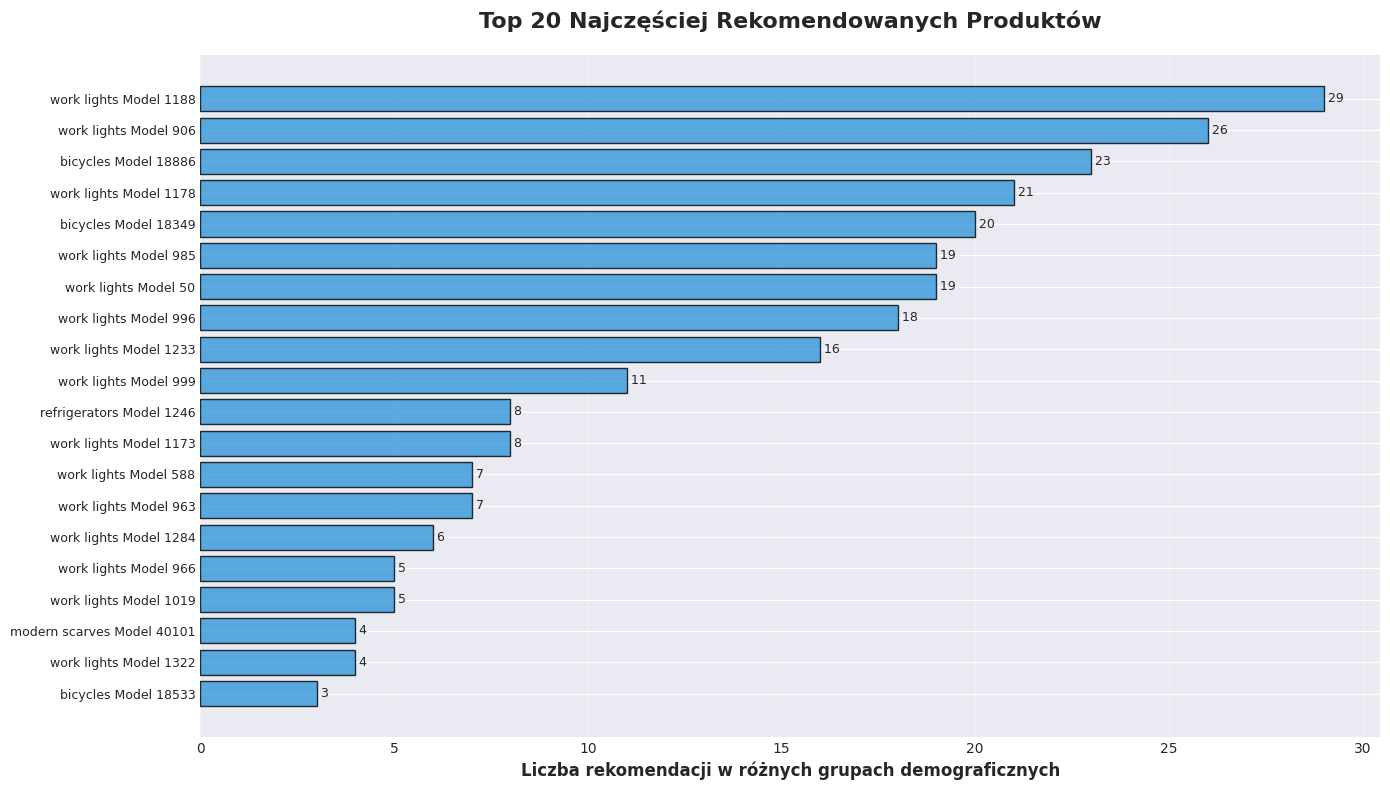

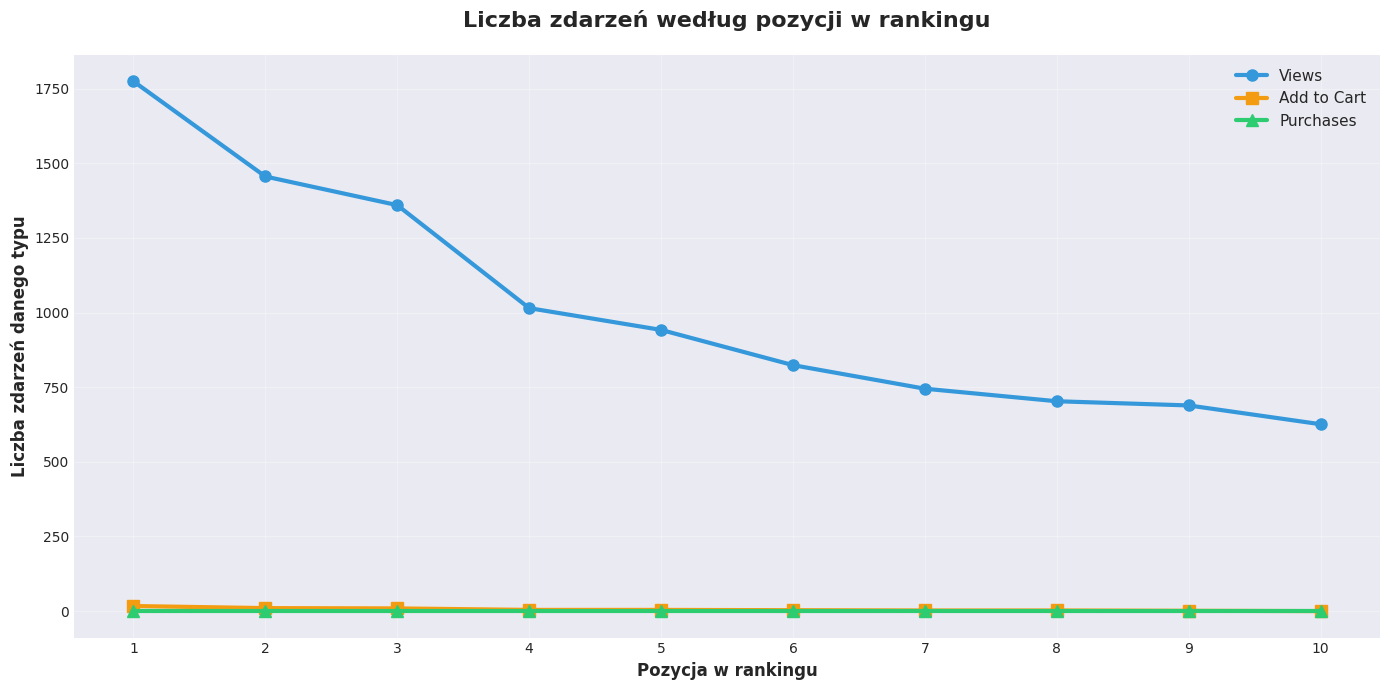


📊 Spadek aktywności z pozycji #1 do #10:
   • Views: 1775 → 626 (35.3%)
   • Cart: 17 → 0 (0.0%)


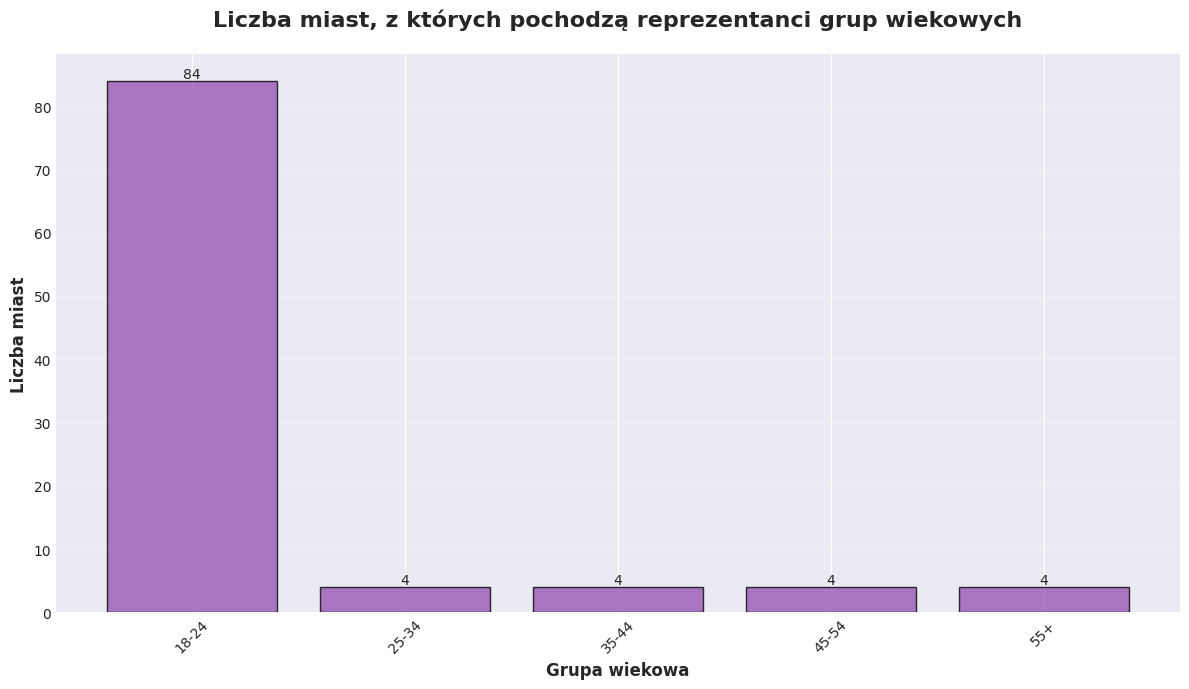


🎯 Top 3 produkty dla każdej grupy wiekowej:

18-24:
   1. work lights Model 1188
   2. work lights Model 906
   3. bicycles Model 18886

25-34:
   1. work lights Model 906
   2. work lights Model 1188
   3. bicycles Model 18886

35-44:
   1. work lights Model 1188
   2. work lights Model 906
   3. work lights Model 985

45-54:
   1. work lights Model 985
   2. work lights Model 906
   3. work lights Model 1188

55+:
   1. work lights Model 1188
   2. work lights Model 906
   3. bicycles Model 18886


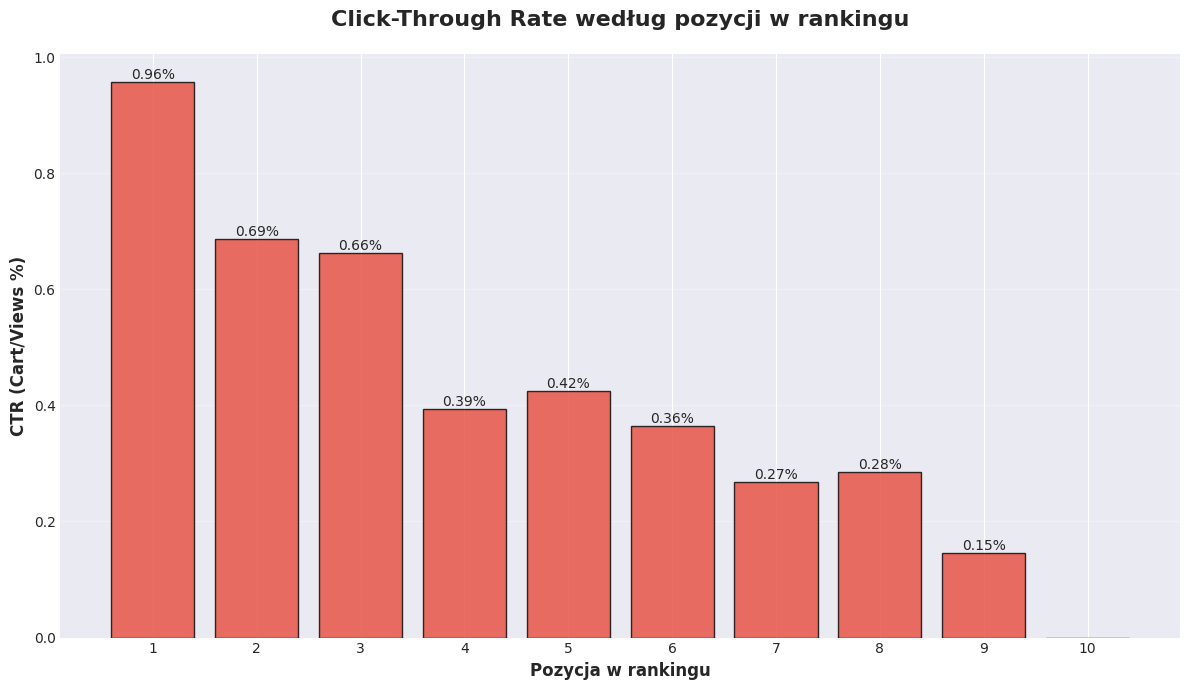


STATYSTYKI SYSTEMU REKOMENDACJI
📊 Ogólne:
   • Liczba grup demograficznych: 100
   • Unikalnych produktów w rekomendacjach: 306
   • Najczęściej rekomendowany: work lights Model 1188 (29x)

📈 Performance rankingu:
   • Rank #1: 1775 views, 17 cart
   • Rank #5: 942 views, 4 cart
   • Rank #10: 626 views, 0 cart

🎯 Skuteczność:
   • Średnie CTR (Top 3 pozycje): 0.77%
   • Średnie CTR (Ostatnie 3 pozycje): 0.14%
   • Różnica: 0.63pp

✓ Połączenie zamknięte


In [25]:
# ============================================================================
# Personalized Recommendations
# ============================================================================

import happybase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

connection = happybase.Connection('localhost', port=9090)
table = connection.table('personalized_recommendations')

data = []
for key, values in table.scan():
    row = {'row_key': key.decode()}
    for col, val in values.items():
        col_name = col.decode().split(':')[1]
        row[col_name] = val.decode()
    data.append(row)

df_recs = pd.DataFrame(data)
print(f"✓ Pobrano {len(df_recs)} segmentów rekomendacji")

# ============================================================================
# WYKRES 1: TOP 20 NAJCZĘŚCIEJ REKOMENDOWANYCH PRODUKTÓW
# ============================================================================
all_products = []
for i in range(1, 11):
    col = f'rank_{i}_product_name'
    if col in df_recs.columns:
        products = df_recs[col].dropna().tolist()
        all_products.extend(products)

product_counts = Counter(all_products).most_common(20)

fig, ax = plt.subplots(figsize=(14, 8))

products = [p[0][:40] for p in product_counts]  # Obetnij nazwy
counts = [p[1] for p in product_counts]

bars = ax.barh(range(len(products)), counts, color='#3498db', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(products)))
ax.set_yticklabels(products, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Liczba rekomendacji w różnych grupach demograficznych', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Najczęściej Rekomendowanych Produktów', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')

for i, val in enumerate(counts):
    ax.text(val, i, f' {int(val)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# WYKRES 2: ROZKŁAD POZYCJI (który rank jest najważniejszy)
# ============================================================================
rank_performance = []

for rank in range(1, 11):
    total_views = 0
    total_cart = 0
    total_purchases = 0
    
    for metric, label in [('views', 'views'), ('add_to_cart', 'cart'), ('purchases', 'purchases')]:
        col = f'rank_{rank}_{metric}'
        if col in df_recs.columns:
            vals = pd.to_numeric(df_recs[col], errors='coerce').fillna(0)
            if label == 'views':
                total_views = vals.sum()
            elif label == 'cart':
                total_cart = vals.sum()
            else:
                total_purchases = vals.sum()
    
    rank_performance.append({
        'rank': rank,
        'views': total_views,
        'cart': total_cart,
        'purchases': total_purchases
    })

df_rank = pd.DataFrame(rank_performance)

fig, ax = plt.subplots(figsize=(14, 7))

x = df_rank['rank']
ax.plot(x, df_rank['views'], marker='o', linewidth=3, markersize=8, 
        label='Views', color='#3498db')
ax.plot(x, df_rank['cart'], marker='s', linewidth=3, markersize=8,
        label='Add to Cart', color='#f39c12')
ax.plot(x, df_rank['purchases'], marker='^', linewidth=3, markersize=8,
        label='Purchases', color='#2ecc71')

ax.set_xlabel('Pozycja w rankingu', fontsize=12, fontweight='bold')
ax.set_ylabel('Liczba zdarzeń danego typu', fontsize=12, fontweight='bold')
ax.set_title('Liczba zdarzeń według pozycji w rankingu', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 11))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Spadek aktywności z pozycji #1 do #10:")
print(f"   • Views: {df_rank.iloc[0]['views']:.0f} → {df_rank.iloc[-1]['views']:.0f} ({(df_rank.iloc[-1]['views']/df_rank.iloc[0]['views']*100):.1f}%)")
if df_rank.iloc[0]['cart'] > 0:
    print(f"   • Cart: {df_rank.iloc[0]['cart']:.0f} → {df_rank.iloc[-1]['cart']:.0f} ({(df_rank.iloc[-1]['cart']/df_rank.iloc[0]['cart']*100):.1f}%)")

# ============================================================================
# WYKRES 3: PORÓWNANIE SEGMENTÓW (age groups)
# ============================================================================
if 'age_group' in df_recs.columns:
    age_recs = {}
    
    for age_group in df_recs['age_group'].unique():
        age_data = df_recs[df_recs['age_group'] == age_group]
        
        products = []
        for i in range(1, 6):  # Top 5
            col = f'rank_{i}_product_name'
            if col in age_data.columns:
                prods = age_data[col].dropna().tolist()
                products.extend(prods)
        
        top_products = Counter(products).most_common(3)
        age_recs[age_group] = [p[0] for p in top_products]
    
    # Wykres liczby segmentów
    age_counts = df_recs['age_group'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    bars = ax.bar(age_counts.index, age_counts.values, 
                  color='#9b59b6', alpha=0.8, edgecolor='black')
    ax.set_ylabel('Liczba miast', fontsize=12, fontweight='bold')
    ax.set_xlabel('Grupa wiekowa', fontsize=12, fontweight='bold')
    ax.set_title('Liczba miast, z których pochodzą reprezentanci grup wiekowych', fontsize=16, fontweight='bold', pad=20)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Pokaż top produkty dla każdej grupy
    print(f"\n🎯 Top 3 produkty dla każdej grupy wiekowej:")
    for age, products in sorted(age_recs.items()):
        print(f"\n{age}:")
        for i, prod in enumerate(products[:3], 1):
            print(f"   {i}. {prod[:50]}")

# ============================================================================
# WYKRES 4: CTR według pozycji (Click-through rate simulation)
# ============================================================================
df_rank['ctr'] = (df_rank['cart'] / df_rank['views'] * 100).fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(df_rank['rank'], df_rank['ctr'], 
              color='#e74c3c', alpha=0.8, edgecolor='black')
ax.set_xlabel('Pozycja w rankingu', fontsize=12, fontweight='bold')
ax.set_ylabel('CTR (Cart/Views %)', fontsize=12, fontweight='bold')
ax.set_title('Click-Through Rate według pozycji w rankingu', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, df_rank['ctr']):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., val,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================================
# STATYSTYKI
# ============================================================================
print("\n" + "="*80)
print("STATYSTYKI SYSTEMU REKOMENDACJI")
print("="*80)
print(f"📊 Ogólne:")
print(f"   • Liczba grup demograficznych: {len(df_recs)}")
print(f"   • Unikalnych produktów w rekomendacjach: {len(set(all_products))}")
print(f"   • Najczęściej rekomendowany: {product_counts[0][0][:50]} ({product_counts[0][1]}x)")

print(f"\n📈 Performance rankingu:")
print(f"   • Rank #1: {df_rank.iloc[0]['views']:.0f} views, {df_rank.iloc[0]['cart']:.0f} cart")
print(f"   • Rank #5: {df_rank.iloc[4]['views']:.0f} views, {df_rank.iloc[4]['cart']:.0f} cart")
print(f"   • Rank #10: {df_rank.iloc[9]['views']:.0f} views, {df_rank.iloc[9]['cart']:.0f} cart")

print(f"\n🎯 Skuteczność:")
avg_ctr_top3 = df_rank.iloc[:3]['ctr'].mean()
avg_ctr_bottom3 = df_rank.iloc[-3:]['ctr'].mean()
print(f"   • Średnie CTR (Top 3 pozycje): {avg_ctr_top3:.2f}%")
print(f"   • Średnie CTR (Ostatnie 3 pozycje): {avg_ctr_bottom3:.2f}%")
print(f"   • Różnica: {avg_ctr_top3 - avg_ctr_bottom3:.2f}pp")

print("="*80)

connection.close()
print("\n✓ Połączenie zamknięte")


## 4. Analiza efektywności marek (Brand Performance)
### Metryki tygodniowe według marek

✓ Pobrano 1503 rekordów z brand_performance
✓ 100 unikalnych marek


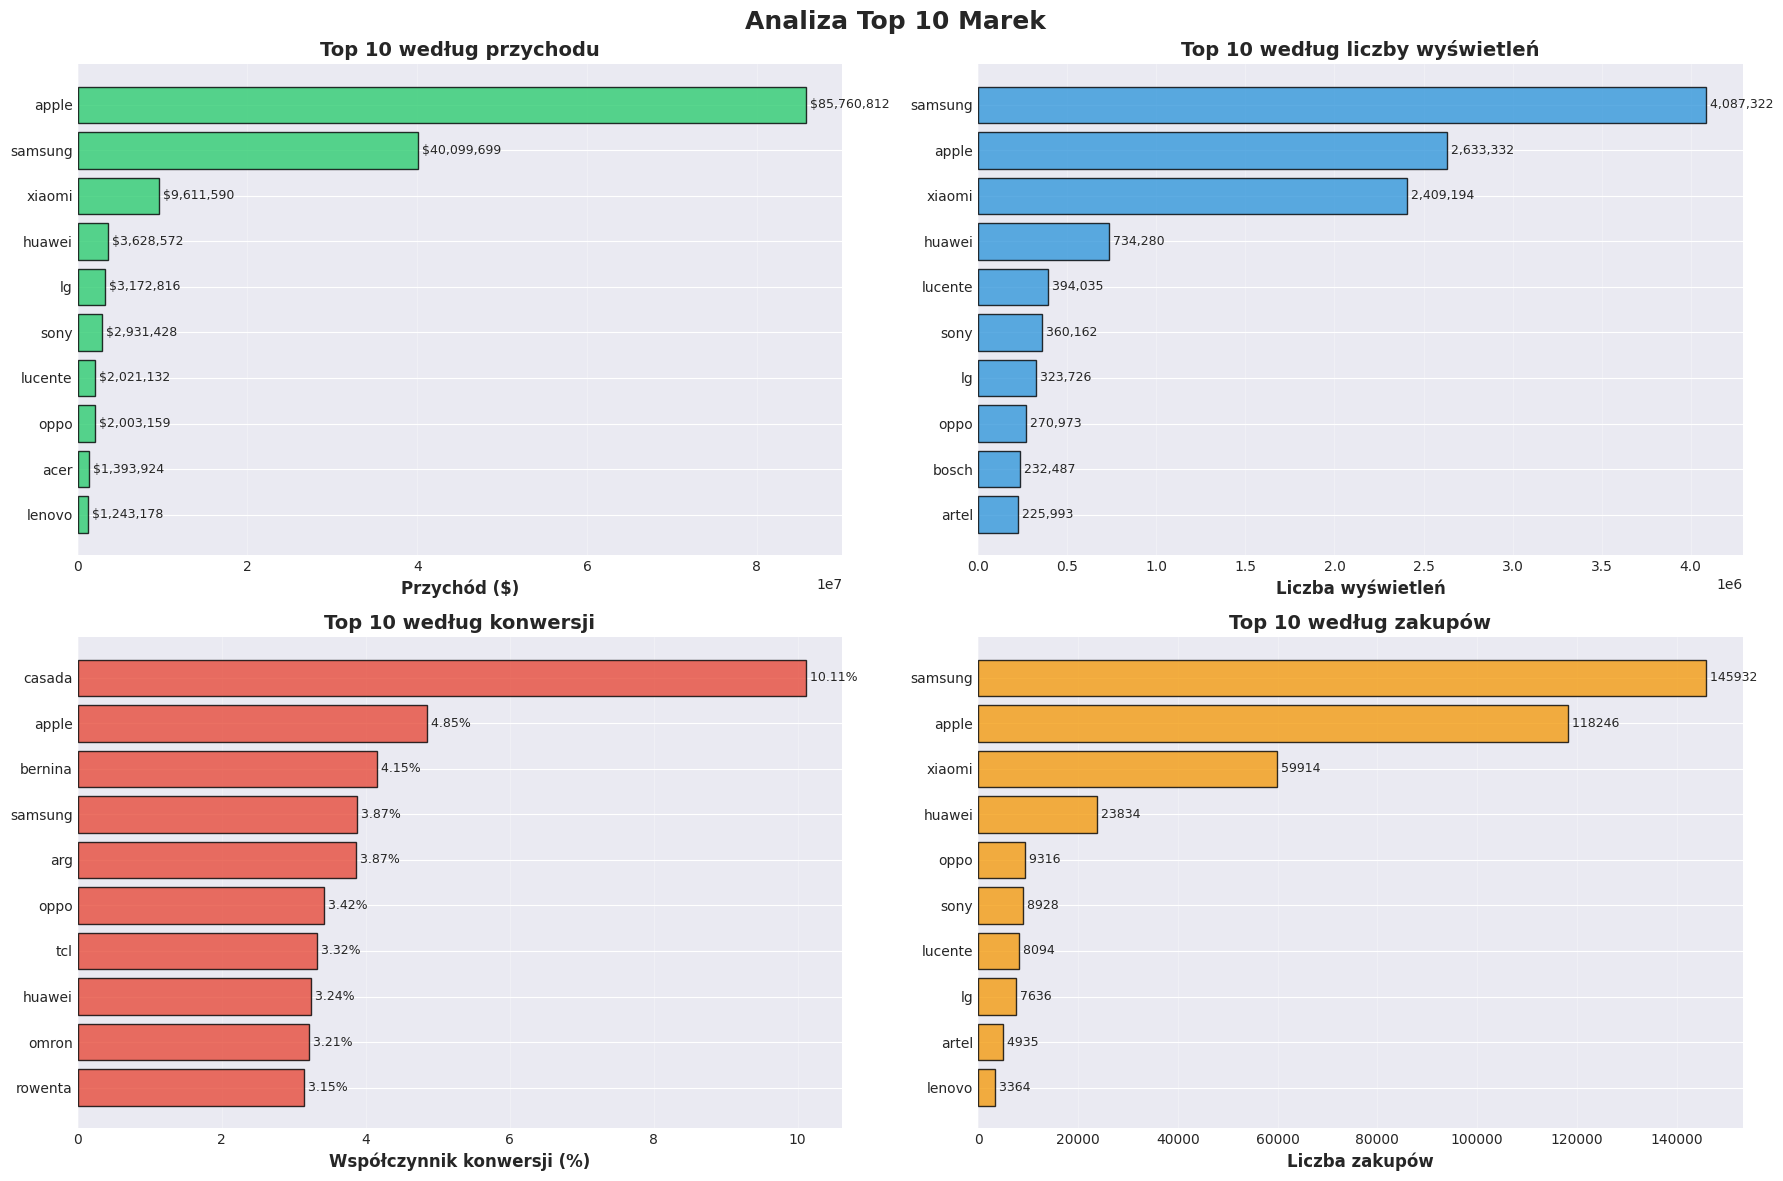

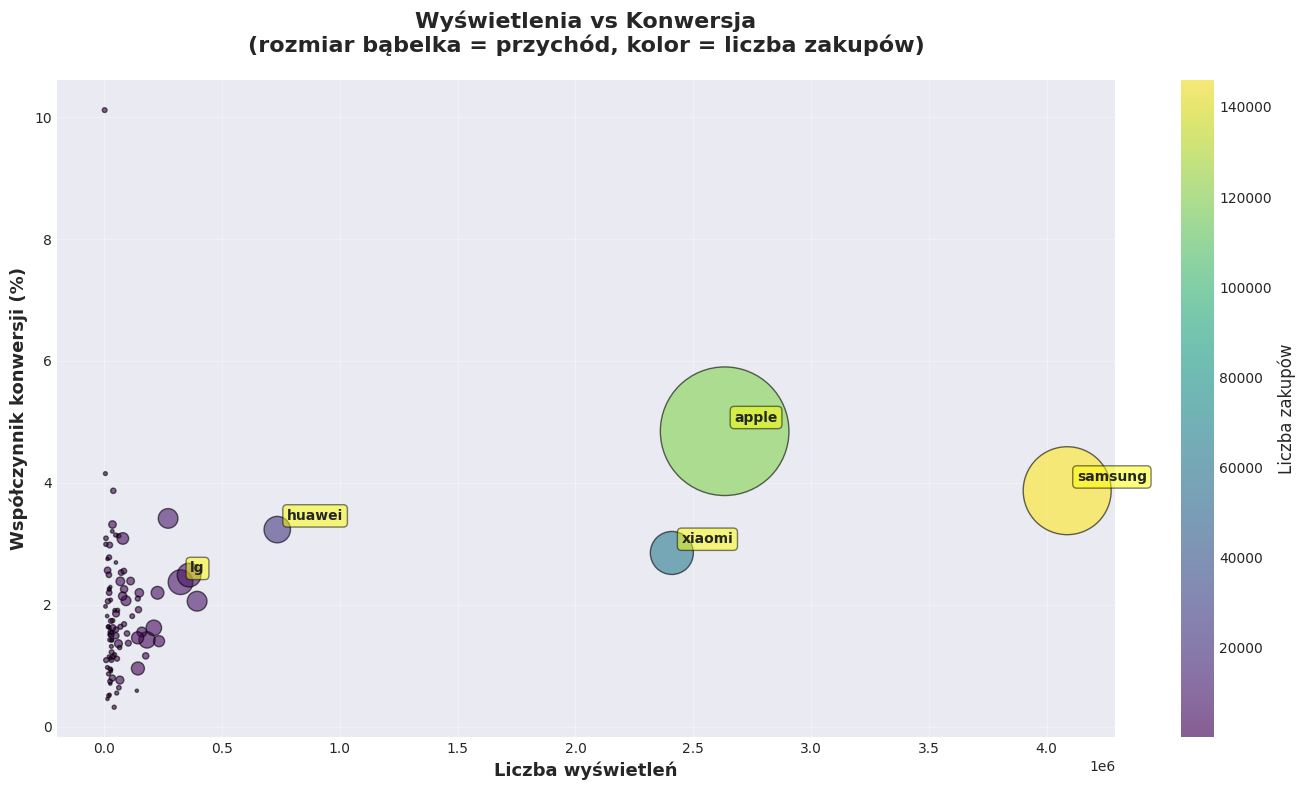

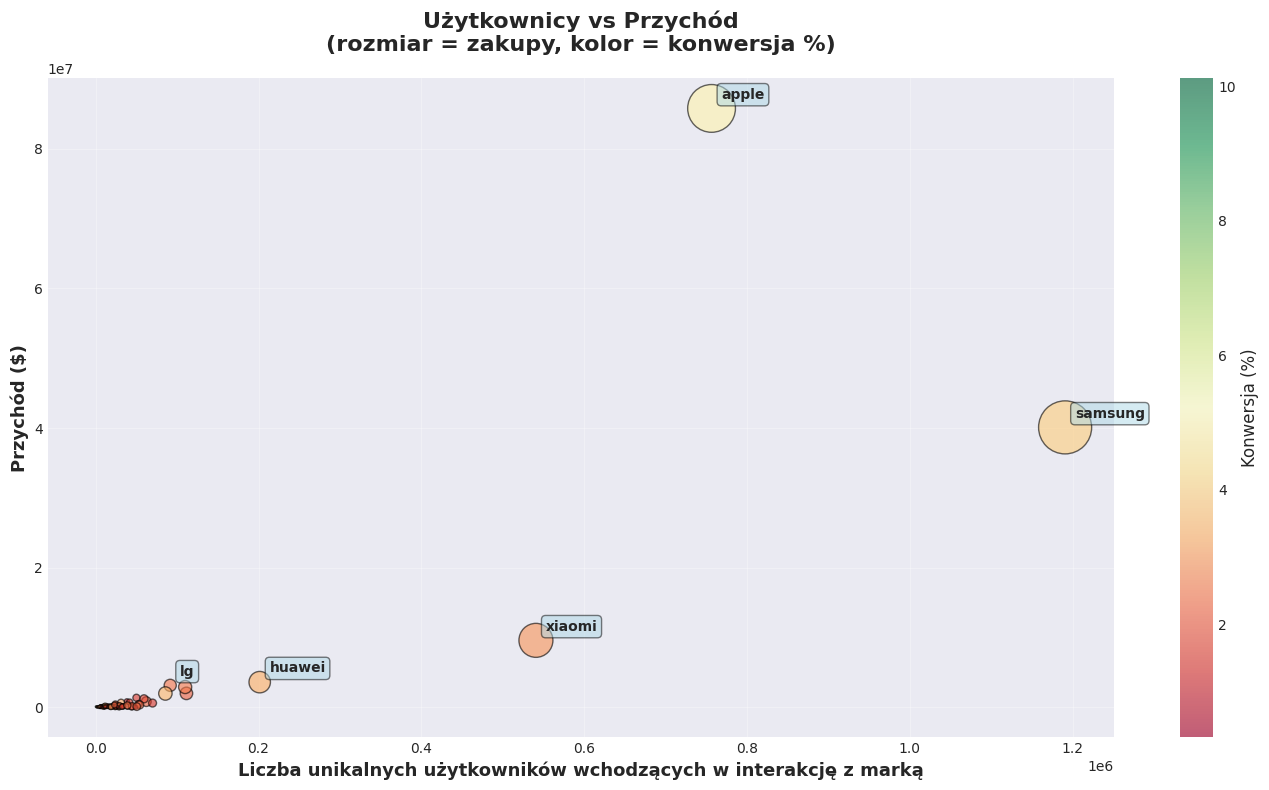

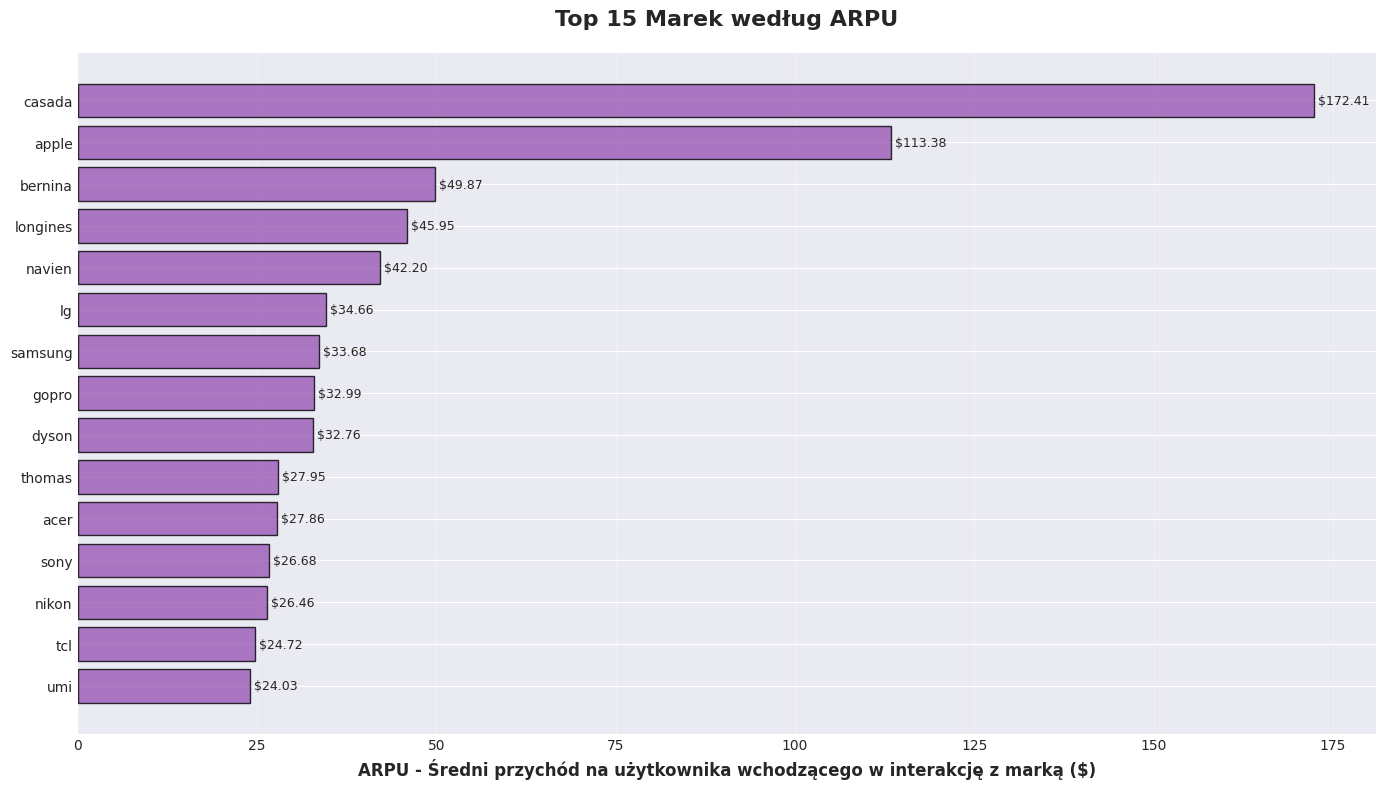


STATYSTYKI BRAND PERFORMANCE

📊 Ogólne:
   • Liczba marek: 100
   • Łączny przychód: $167,289,847.31
   • Łączne wyświetlenia: 16,408,782
   • Łączne zakupy: 470919
   • Średnia konwersja: 1.95%

🏆 Top 3 marki według przychodu:
   1. apple: $85,760,812.24 (118246 zakupów, 4.85% konwersja)
   2. samsung: $40,099,698.56 (145932 zakupów, 3.87% konwersja)
   3. xiaomi: $9,611,589.74 (59914 zakupów, 2.85% konwersja)

⚡ Top 3 marki według konwersji:
   1. casada: 10.11% (1628 views, 174 zakupów)
   2. apple: 4.85% (2633332 views, 118246 zakupów)
   3. bernina: 4.15% (4716 views, 177 zakupów)

💰 Top 3 marki według ARPU:
   1. casada: $172.41/user (677 użytkowników)
   2. apple: $113.38/user (756380 użytkowników)
   3. bernina: $49.87/user (1524 użytkowników)

📈 Insights:
   • Marek z wysokim ruchem (>Q3): 25
   • Średnia konwersja top quartile: 2.12%
   • Najwyższe ARPU: casada ($172.41)

✓ Połączenie zamknięte


In [28]:
# ============================================================================
# Brand Performance
# ============================================================================

import happybase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

connection = happybase.Connection('localhost', port=9090)
table = connection.table('brand_performance')

# Pobierz dane
data = []
for key, values in table.scan():
    row = {'row_key': key.decode()}
    for col, val in values.items():
        col_name = col.decode().split(':')[1]
        row[col_name] = val.decode()
    data.append(row)

df_brands = pd.DataFrame(data)
print(f"✓ Pobrano {len(df_brands)} rekordów z brand_performance")

# Konwersja numeryczna
numeric_cols = ['total_views', 'total_purchases', 'total_revenue', 'unique_users', 'conversion_rate']
for col in numeric_cols:
    if col in df_brands.columns:
        df_brands[col] = pd.to_numeric(df_brands[col], errors='coerce').fillna(0)

# Agregacja (jeśli są duplikaty)
df_brands_agg = df_brands.groupby('brand').agg({
    'total_views': 'sum',
    'total_purchases': 'sum',
    'total_revenue': 'sum',
    'unique_users': 'sum',
    'conversion_rate': 'mean'
}).reset_index()

print(f"✓ {len(df_brands_agg)} unikalnych marek")

# ============================================================================
# WYKRES 1: TOP 10 MAREK - 4 panele
# ============================================================================
top_brands = df_brands_agg.nlargest(10, 'total_revenue')
top_brands_views = df_brands_agg.nlargest(10, 'total_views')
top_brands_conv = df_brands_agg.nlargest(10, 'conversion_rate')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Analiza Top 10 Marek', fontsize=18, fontweight='bold')

# 1. Przychód
ax1 = axes[0, 0]
bars1 = ax1.barh(range(len(top_brands)), top_brands['total_revenue'], 
                 color='#2ecc71', alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(top_brands)))
ax1.set_yticklabels(top_brands['brand'], fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Przychód ($)', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 według przychodu', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

for i, val in enumerate(top_brands['total_revenue']):
    ax1.text(val, i, f' ${val:,.0f}', va='center', fontsize=9)

# 2. Wyświetlenia
ax2 = axes[0, 1]
bars2 = ax2.barh(range(len(top_brands_views)), top_brands_views['total_views'], 
                 color='#3498db', alpha=0.8, edgecolor='black')
ax2.set_yticks(range(len(top_brands_views)))
ax2.set_yticklabels(top_brands_views['brand'], fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Liczba wyświetleń', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 według liczby wyświetleń', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

for i, val in enumerate(top_brands_views['total_views']):
    ax2.text(val, i, f' {int(val):,}', va='center', fontsize=9)

# 3. Konwersja
ax3 = axes[1, 0]
bars3 = ax3.barh(range(len(top_brands_conv)), top_brands_conv['conversion_rate']*100, 
                 color='#e74c3c', alpha=0.8, edgecolor='black')
ax3.set_yticks(range(len(top_brands_conv)))
ax3.set_yticklabels(top_brands_conv['brand'], fontsize=10)
ax3.invert_yaxis()
ax3.set_xlabel('Współczynnik konwersji (%)', fontsize=12, fontweight='bold')
ax3.set_title('Top 10 według konwersji', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

for i, val in enumerate(top_brands_conv['conversion_rate']*100):
    ax3.text(val, i, f' {val:.2f}%', va='center', fontsize=9)

# 4. Zakupy (POSORTOWANE według zakupów)
top_brands_purchases = df_brands_agg.nlargest(10, 'total_purchases')

ax4 = axes[1, 1]
bars4 = ax4.barh(range(len(top_brands_purchases)), top_brands_purchases['total_purchases'], 
                 color='#f39c12', alpha=0.8, edgecolor='black')
ax4.set_yticks(range(len(top_brands_purchases)))
ax4.set_yticklabels(top_brands_purchases['brand'], fontsize=10)
ax4.invert_yaxis()
ax4.set_xlabel('Liczba zakupów', fontsize=12, fontweight='bold')
ax4.set_title('Top 10 według zakupów', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

for i, val in enumerate(top_brands_purchases['total_purchases']):
    ax4.text(val, i, f' {int(val)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================================
# WYKRES 2: SCATTER - Wyświetlenia vs Konwersja
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(df_brands_agg['total_views'], 
                     df_brands_agg['conversion_rate']*100,
                     s=df_brands_agg['total_revenue']/10000,  # rozmiar = przychód
                     alpha=0.6, 
                     c=df_brands_agg['total_purchases'], 
                     cmap='viridis', 
                     edgecolors='black', 
                     linewidth=1)

ax.set_title('Wyświetlenia vs Konwersja\n(rozmiar bąbelka = przychód, kolor = liczba zakupów)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Liczba wyświetleń', fontsize=13, fontweight='bold')
ax.set_ylabel('Współczynnik konwersji (%)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Liczba zakupów', fontsize=12)

# Etykiety dla top 5 marek
top_5_revenue = df_brands_agg.nlargest(5, 'total_revenue')
for idx, row in top_5_revenue.iterrows():
    ax.annotate(row['brand'], 
                (row['total_views'], row['conversion_rate']*100),
                xytext=(7, 7), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================================================
# WYKRES 3: Przychód vs Liczba Użytkowników
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

scatter2 = ax.scatter(df_brands_agg['unique_users'], 
                      df_brands_agg['total_revenue'],
                      s=df_brands_agg['total_purchases']/100,
                      alpha=0.6,
                      c=df_brands_agg['conversion_rate']*100,
                      cmap='RdYlGn',
                      edgecolors='black',
                      linewidth=1)

ax.set_title('Użytkownicy vs Przychód\n(rozmiar = zakupy, kolor = konwersja %)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Liczba unikalnych użytkowników wchodzących w interakcję z marką', fontsize=13, fontweight='bold')
ax.set_ylabel('Przychód ($)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar2 = plt.colorbar(scatter2, ax=ax)
cbar2.set_label('Konwersja (%)', fontsize=12)

# Etykiety dla top 5
for idx, row in top_5_revenue.iterrows():
    ax.annotate(row['brand'], 
                (row['unique_users'], row['total_revenue']),
                xytext=(7, 7), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================================================
# WYKRES 4: Average Revenue Per User (ARPU)
# ============================================================================
df_brands_agg['arpu'] = (df_brands_agg['total_revenue'] / df_brands_agg['unique_users']).fillna(0)
top_arpu = df_brands_agg.nlargest(15, 'arpu')

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(range(len(top_arpu)), top_arpu['arpu'], 
               color='#9b59b6', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(top_arpu)))
ax.set_yticklabels(top_arpu['brand'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('ARPU - Średni przychód na użytkownika wchodzącego w interakcję z marką ($)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Marek według ARPU', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')

for i, val in enumerate(top_arpu['arpu']):
    ax.text(val, i, f' ${val:,.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# STATYSTYKI
# ============================================================================
print("\n" + "="*80)
print("STATYSTYKI BRAND PERFORMANCE")
print("="*80)

print(f"\n📊 Ogólne:")
print(f"   • Liczba marek: {len(df_brands_agg)}")
print(f"   • Łączny przychód: ${df_brands_agg['total_revenue'].sum():,.2f}")
print(f"   • Łączne wyświetlenia: {df_brands_agg['total_views'].sum():,.0f}")
print(f"   • Łączne zakupy: {df_brands_agg['total_purchases'].sum():.0f}")
print(f"   • Średnia konwersja: {df_brands_agg['conversion_rate'].mean()*100:.2f}%")

print(f"\n🏆 Top 3 marki według przychodu:")
for i, (idx, row) in enumerate(top_brands.head(3).iterrows(), 1):
    print(f"   {i}. {row['brand']}: ${row['total_revenue']:,.2f} ({row['total_purchases']:.0f} zakupów, {row['conversion_rate']*100:.2f}% konwersja)")

print(f"\n⚡ Top 3 marki według konwersji:")
for i, (idx, row) in enumerate(top_brands_conv.head(3).iterrows(), 1):
    print(f"   {i}. {row['brand']}: {row['conversion_rate']*100:.2f}% ({row['total_views']:.0f} views, {row['total_purchases']:.0f} zakupów)")

print(f"\n💰 Top 3 marki według ARPU:")
for i, (idx, row) in enumerate(top_arpu.head(3).iterrows(), 1):
    print(f"   {i}. {row['brand']}: ${row['arpu']:,.2f}/user ({row['unique_users']:.0f} użytkowników)")

print(f"\n📈 Insights:")
high_volume = df_brands_agg[df_brands_agg['total_views'] > df_brands_agg['total_views'].quantile(0.75)]
print(f"   • Marek z wysokim ruchem (>Q3): {len(high_volume)}")
print(f"   • Średnia konwersja top quartile: {high_volume['conversion_rate'].mean()*100:.2f}%")
print(f"   • Najwyższe ARPU: {top_arpu.iloc[0]['brand']} (${top_arpu.iloc[0]['arpu']:,.2f})")

print("="*80)

connection.close()
print("\n✓ Połączenie zamknięte")
